# Final Experiments

This notebook is the single entrypoint for all post-preprocessing experiments:

- leakage-safe nested tuning
- final grouped model comparison
- ablation study
- segment analysis
- top-k strategy analysis

Run order:

1. run `leakage_safe_preprocess.py`
2. update the config cell below if needed
3. run the notebook top to bottom on the cloud machine


## Design Notes

This notebook intentionally rebuilds all leakage-sensitive learned features inside grouped train folds only.

That means the following are **not** loaded from a global final feature table:

- KMeans clusters
- cluster-product target encoding
- Apriori rule hits
- ALS features

Only globally safe base tables are read from the preprocessing bundle.


In [1]:
from __future__ import annotations

import ast
import json
import math
import os
import platform
import subprocess
import sys
from collections import Counter
from pathlib import Path

os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")
os.environ.setdefault("VECLIB_MAXIMUM_THREADS", "1")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, f1_score, log_loss, precision_score, recall_score, roc_auc_score, silhouette_score
from sklearn.model_selection import GroupKFold, ParameterSampler
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    from threadpoolctl import threadpool_limits
    threadpool_limits(1, "blas")
    HAS_THREADPOOLCTL = True
except Exception:
    HAS_THREADPOOLCTL = False

try:
    import lightgbm as lgb
    HAS_LIGHTGBM = True
except Exception:
    HAS_LIGHTGBM = False

try:
    from catboost import CatBoostClassifier
    HAS_CATBOOST = True
except Exception:
    HAS_CATBOOST = False

try:
    import implicit
    from scipy import sparse
    HAS_IMPLICIT = True
except Exception:
    HAS_IMPLICIT = False

def detect_nvidia_gpu():
    try:
        result = subprocess.run(
            ["nvidia-smi", "-L"],
            capture_output=True,
            text=True,
            check=False,
        )
        return result.returncode == 0 and "GPU " in (result.stdout or "")
    except Exception:
        return False

HAS_NVIDIA_GPU = detect_nvidia_gpu()

print({
    "python": sys.version.split()[0],
    "platform": platform.platform(),
    "HAS_LIGHTGBM": HAS_LIGHTGBM,
    "HAS_CATBOOST": HAS_CATBOOST,
    "HAS_IMPLICIT": HAS_IMPLICIT,
    "HAS_NVIDIA_GPU": HAS_NVIDIA_GPU,
    "HAS_THREADPOOLCTL": HAS_THREADPOOLCTL,
    "OPENBLAS_NUM_THREADS": os.environ.get("OPENBLAS_NUM_THREADS"),
})


{'python': '3.12.13', 'platform': 'Linux-5.15.0-131-generic-x86_64-with-glibc2.39', 'HAS_LIGHTGBM': True, 'HAS_CATBOOST': True, 'HAS_IMPLICIT': True, 'HAS_NVIDIA_GPU': True, 'HAS_THREADPOOLCTL': True, 'OPENBLAS_NUM_THREADS': '1'}


In [2]:
BASE_DIR = Path.cwd().resolve()
if (BASE_DIR / "Final version").exists():
    PROJECT_ROOT = BASE_DIR
    WORKDIR = BASE_DIR / "Final version"
else:
    PROJECT_ROOT = BASE_DIR.parent if BASE_DIR.name == "Final version" else BASE_DIR
    WORKDIR = BASE_DIR if BASE_DIR.name == "Final version" else BASE_DIR

BUNDLE_DIR = WORKDIR / "artifacts" / "base_bundle"
OUTPUT_DIR = WORKDIR / "artifacts" / "experiment_outputs"

RANDOM_STATE = 42

# Debug knobs
SAMPLE_USERS = None
KMEANS_N_CLUSTERS = 4
TRAIN_RATIO = 0.70
VALIDATION_RATIO = 0.15
TOP_K_FIXED = 11
TOPK_STRATEGIES = ["fixed_11", "rounded_avg_basket", "ceil_avg_basket"]

# Runtime knobs
USE_GPU_FOR_CATBOOST = bool(HAS_CATBOOST and HAS_NVIDIA_GPU)
CATBOOST_GPU_DEVICE = "0"
RUN_MAIN_TUNING = True
RUN_ABLATION = True
RUN_SEGMENT_ANALYSIS = True
RUN_TOPK_ANALYSIS = True
RUN_KMEANS_APRIORI_DIAGNOSTICS = True
REQUIRE_IMPLICIT_FOR_ALS = True

# Keep ablation tractable on cloud
ABLATION_MODELS = ["LightGBM", "CatBoost"]

# Search budgets
N_ITER_SEARCH = {
    "LogisticRegression_SAGA": 10,
    "LightGBM": 12,
    "MLP": 10,
    "CatBoost": 10,
}

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print({
    "PROJECT_ROOT": str(PROJECT_ROOT),
    "WORKDIR": str(WORKDIR),
    "BUNDLE_DIR": str(BUNDLE_DIR),
    "OUTPUT_DIR": str(OUTPUT_DIR),
    "USE_GPU_FOR_CATBOOST": USE_GPU_FOR_CATBOOST,
    "CATBOOST_GPU_DEVICE": CATBOOST_GPU_DEVICE,
    "REQUIRE_IMPLICIT_FOR_ALS": REQUIRE_IMPLICIT_FOR_ALS,
})


{'PROJECT_ROOT': '/', 'WORKDIR': '/', 'BUNDLE_DIR': '/artifacts/base_bundle', 'OUTPUT_DIR': '/artifacts/experiment_outputs', 'USE_GPU_FOR_CATBOOST': True, 'CATBOOST_GPU_DEVICE': '0', 'REQUIRE_IMPLICIT_FOR_ALS': True}


In [3]:
metadata = json.loads((BUNDLE_DIR / "bundle_metadata.json").read_text())

bundle = {
    "orders_enriched": pd.read_parquet(BUNDLE_DIR / "orders_enriched.parquet"),
    "product_meta": pd.read_parquet(BUNDLE_DIR / "product_meta.parquet"),
    "prior_detail": pd.read_parquet(BUNDLE_DIR / "prior_detail.parquet"),
    "history_detail": pd.read_parquet(BUNDLE_DIR / "history_detail.parquet"),
    "target_orders": pd.read_parquet(BUNDLE_DIR / "target_orders.parquet"),
    "target_detail": pd.read_parquet(BUNDLE_DIR / "target_detail.parquet"),
    "labels": pd.read_parquet(BUNDLE_DIR / "labels.parquet"),
    "candidate_universe": pd.read_parquet(BUNDLE_DIR / "candidate_universe.parquet"),
    "user_last_history_order": pd.read_parquet(BUNDLE_DIR / "user_last_history_order.parquet"),
    "last_history_products": pd.read_parquet(BUNDLE_DIR / "last_history_products.parquet"),
    "order_level_history": pd.read_parquet(BUNDLE_DIR / "order_level_history.parquet"),
}

all_users = np.sort(bundle["target_orders"]["user_id"].unique())
if SAMPLE_USERS is not None:
    rng = np.random.default_rng(RANDOM_STATE)
    all_users = np.sort(rng.choice(all_users, size=min(SAMPLE_USERS, len(all_users)), replace=False))

bundle["target_orders"] = bundle["target_orders"][bundle["target_orders"]["user_id"].isin(all_users)].copy()
bundle["labels"] = bundle["labels"][bundle["labels"]["user_id"].isin(all_users)].copy()
bundle["candidate_universe"] = bundle["candidate_universe"][bundle["candidate_universe"]["user_id"].isin(all_users)].copy()
bundle["prior_detail"] = bundle["prior_detail"][bundle["prior_detail"]["user_id"].isin(all_users)].copy()
bundle["history_detail"] = bundle["history_detail"][bundle["history_detail"]["user_id"].isin(all_users)].copy()
bundle["user_last_history_order"] = bundle["user_last_history_order"][bundle["user_last_history_order"]["user_id"].isin(all_users)].copy()
bundle["last_history_products"] = bundle["last_history_products"][bundle["last_history_products"]["user_id"].isin(all_users)].copy()
bundle["order_level_history"] = bundle["order_level_history"][bundle["order_level_history"]["user_id"].isin(all_users)].copy()

print({
    "n_users": int(len(all_users)),
    "prior_rows": int(len(bundle["prior_detail"])),
    "history_rows": int(len(bundle["history_detail"])),
    "candidate_rows": int(len(bundle["candidate_universe"])),
    "positive_pairs": int(len(bundle["labels"])),
})

rng = np.random.default_rng(RANDOM_STATE)
shuffled_users = rng.permutation(all_users)
n_total = len(shuffled_users)
n_train = int(n_total * TRAIN_RATIO)
n_val = int(n_total * VALIDATION_RATIO)
n_test = n_total - n_train - n_val

if min(n_train, n_val, n_test) <= 0:
    raise ValueError("Train / validation / test split is invalid. Adjust TRAIN_RATIO and VALIDATION_RATIO.")

train_users = np.sort(shuffled_users[:n_train])
val_users = np.sort(shuffled_users[n_train:n_train + n_val])
test_users = np.sort(shuffled_users[n_train + n_val:])

split_overview = pd.DataFrame([
    {"split": "train", "users": len(train_users)},
    {"split": "validation", "users": len(val_users)},
    {"split": "test", "users": len(test_users)},
])
display(split_overview)


{'n_users': 206209, 'prior_rows': 32365344, 'history_rows': 31588436, 'candidate_rows': 12945247, 'positive_pairs': 2153274}


,split,users
0,train,144346
1,validation,30931
2,test,30932


In [4]:
def eval_row_level(y_true, y_prob):
    y_prob = np.asarray(y_prob, dtype=float)
    y_true = np.asarray(y_true, dtype=int)
    y_prob_clip = np.clip(y_prob, 1e-15, 1 - 1e-15)
    return {
        "auc": roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan,
        "pr_auc": average_precision_score(y_true, y_prob),
        "logloss": log_loss(y_true, y_prob_clip),
    }


def make_k_map(df_input: pd.DataFrame, strategy: str) -> dict[int, int]:
    user_k = df_input.groupby("user_id")["u_avg_basket_size"].first().reset_index()
    if strategy == "fixed_11":
        user_k["pred_k"] = TOP_K_FIXED
    elif strategy == "rounded_avg_basket":
        user_k["pred_k"] = np.rint(user_k["u_avg_basket_size"]).astype(int).clip(lower=1)
    elif strategy == "ceil_avg_basket":
        user_k["pred_k"] = np.ceil(user_k["u_avg_basket_size"]).astype(int).clip(lower=1)
    else:
        raise ValueError(strategy)
    return dict(zip(user_k["user_id"], user_k["pred_k"]))


def eval_order_with_k_map(df_eval: pd.DataFrame, k_map: dict[int, int], prefix: str):
    ranked = df_eval.sort_values(["user_id", "prob", "product_id"], ascending=[True, False, True]).copy()
    ranked["rank_within_user"] = ranked.groupby("user_id").cumcount() + 1
    ranked["pred_k"] = ranked["user_id"].map(k_map).fillna(TOP_K_FIXED).astype(int).clip(lower=1)
    ranked["pred_topk"] = (ranked["rank_within_user"] <= ranked["pred_k"]).astype(int)

    precision_vals, recall_vals, f1_vals, hit_vals, avgk_vals = [], [], [], [], []
    for _, g in ranked.groupby("user_id"):
        y_t = g["label"].to_numpy()
        y_p = g["pred_topk"].to_numpy()
        precision_vals.append(precision_score(y_t, y_p, zero_division=0))
        recall_vals.append(recall_score(y_t, y_p, zero_division=0))
        f1_vals.append(f1_score(y_t, y_p, zero_division=0))
        hit_vals.append(float((g.loc[g["pred_topk"] == 1, "label"].sum() > 0)))
        avgk_vals.append(float(g["pred_k"].iloc[0]))

    return {
        f"precision@{prefix}": float(np.mean(precision_vals)),
        f"recall@{prefix}": float(np.mean(recall_vals)),
        f"f1@{prefix}": float(np.mean(f1_vals)),
        f"hit@{prefix}": float(np.mean(hit_vals)),
        f"avg_k@{prefix}": float(np.mean(avgk_vals)),
    }


def evaluate_prediction_frame(df_pred: pd.DataFrame, dynamic_strategy: str = "rounded_avg_basket") -> dict:
    row = {}
    row.update(eval_row_level(df_pred["label"].to_numpy(), df_pred["prob"].to_numpy()))
    fixed_map = make_k_map(df_pred, "fixed_11")
    dynamic_map = make_k_map(df_pred, dynamic_strategy)
    row.update(eval_order_with_k_map(df_pred[["user_id", "product_id", "label", "u_avg_basket_size", "prob"]].copy(), fixed_map, "11"))
    row.update(eval_order_with_k_map(df_pred[["user_id", "product_id", "label", "u_avg_basket_size", "prob"]].copy(), dynamic_map, "dynamic_k"))
    return row


In [5]:
def build_aisle_rules(single_counts, pair_counts, n_baskets, min_support, min_confidence, min_lift):
    rows = []
    for (a, b), pair_cnt in pair_counts.items():
        support = pair_cnt / n_baskets
        conf_a_to_b = pair_cnt / single_counts[a]
        conf_b_to_a = pair_cnt / single_counts[b]
        lift_a_to_b = conf_a_to_b / (single_counts[b] / n_baskets)
        lift_b_to_a = conf_b_to_a / (single_counts[a] / n_baskets)
        rows.append({"antecedent": a, "consequent": b, "support": support, "confidence": conf_a_to_b, "lift": lift_a_to_b})
        rows.append({"antecedent": b, "consequent": a, "support": support, "confidence": conf_b_to_a, "lift": lift_b_to_a})

    rules = pd.DataFrame(rows)
    if rules.empty:
        return rules

    rules = rules[
        (rules["support"] >= min_support)
        & (rules["confidence"] >= min_confidence)
        & (rules["lift"] >= min_lift)
    ].copy()
    if rules.empty:
        return rules
    return rules.sort_values(["lift", "confidence", "support"], ascending=[False, False, False]).reset_index(drop=True)


def compute_user_features(prior_df: pd.DataFrame) -> pd.DataFrame:
    order_sizes = prior_df.groupby(["user_id", "order_id"]).size().rename("basket_size").reset_index()
    user_feat = (
        prior_df.groupby("user_id").agg(
            u_total_items=("product_id", "size"),
            u_unique_products=("product_id", "nunique"),
            u_total_orders=("order_number", "max"),
            u_reorder_ratio=("reordered", "mean"),
            u_avg_days_between_orders=("days_since_prior_order", "mean"),
        ).reset_index()
    )
    basket_means = order_sizes.groupby("user_id")["basket_size"].mean().rename("u_avg_basket_size").reset_index()
    user_feat = user_feat.merge(basket_means, on="user_id", how="left")
    return user_feat


def compute_product_features(prior_df: pd.DataFrame) -> pd.DataFrame:
    return (
        prior_df.groupby("product_id").agg(
            p_total_purchases=("order_id", "size"),
            p_unique_users=("user_id", "nunique"),
            p_reorder_ratio=("reordered", "mean"),
            p_avg_cart_order=("add_to_cart_order", "mean"),
        ).reset_index()
    )


def compute_user_product_features(prior_df: pd.DataFrame) -> pd.DataFrame:
    up = (
        prior_df.groupby(["user_id", "product_id"]).agg(
            up_buy_cnt=("order_id", "size"),
            up_reorder_cnt=("reordered", "sum"),
            up_last_order=("order_number", "max"),
            up_first_order=("order_number", "min"),
            up_avg_cart_order=("add_to_cart_order", "mean"),
        ).reset_index()
    )
    up["up_reorder_ratio"] = up["up_reorder_cnt"] / up["up_buy_cnt"].replace(0, np.nan)
    return up


def build_candidate_frame_for_users(user_ids: np.ndarray) -> pd.DataFrame:
    frame = (
        bundle["candidate_universe"][bundle["candidate_universe"]["user_id"].isin(user_ids)]
        .merge(bundle["target_orders"][["user_id", "target_order_number"]], on="user_id", how="left")
        .merge(bundle["labels"], on=["user_id", "product_id"], how="left")
        .merge(bundle["product_meta"][["product_id", "aisle_id", "department_id", "aisle_name"]], on="product_id", how="left")
        .copy()
    )
    frame["label"] = frame["label"].fillna(0).astype(int)
    return frame


def add_base_history_features(frame: pd.DataFrame, user_feat: pd.DataFrame, up_feat: pd.DataFrame, product_feat: pd.DataFrame) -> pd.DataFrame:
    out = (
        frame.merge(user_feat, on="user_id", how="left")
        .merge(up_feat, on=["user_id", "product_id"], how="left")
        .merge(product_feat, on="product_id", how="left")
    )
    out["up_orders_since_last"] = (out["target_order_number"] - out["up_last_order"]).clip(lower=0)
    out["up_freq"] = out["up_buy_cnt"] / out["u_total_orders"].replace(0, np.nan)
    out["up_days_since_last"] = out["up_orders_since_last"] * out["u_avg_days_between_orders"]
    return out


def build_last_basket_aisles(prior_df: pd.DataFrame) -> dict[int, set]:
    last_orders = (
        prior_df.groupby("user_id")["order_number"].max().rename("last_order_number").reset_index()
    )
    last_baskets = prior_df.merge(last_orders, on="user_id", how="inner")
    last_baskets = last_baskets[last_baskets["order_number"] == last_baskets["last_order_number"]]
    aisle_sets = (
        last_baskets.groupby("user_id")["aisle_name"]
        .apply(lambda x: set(x.dropna().astype(str)))
    )
    return dict(aisle_sets)


def build_apriori_artifacts(train_prior: pd.DataFrame):
    basket_aisles = (
        train_prior.groupby("order_id")["aisle_name"]
        .apply(lambda x: sorted(set(x.dropna().astype(str))))
        .reset_index(name="aisle_basket")
    )
    basket_aisles = basket_aisles[basket_aisles["aisle_basket"].str.len() >= 2].copy()

    single_counts, pair_counts = {}, {}
    for basket in basket_aisles["aisle_basket"]:
        for item in basket:
            single_counts[item] = single_counts.get(item, 0) + 1
        for i in range(len(basket)):
            for j in range(i + 1, len(basket)):
                pair = (basket[i], basket[j])
                pair_counts[pair] = pair_counts.get(pair, 0) + 1

    rules = build_aisle_rules(
        single_counts=single_counts,
        pair_counts=pair_counts,
        n_baskets=max(len(basket_aisles), 1),
        min_support=0.01,
        min_confidence=0.30,
        min_lift=1.30,
    )

    ante_to_cons = {}
    if not rules.empty:
        for a, b in rules[["antecedent", "consequent"]].itertuples(index=False):
            ante_to_cons.setdefault(a, set()).add(b)
    return rules, ante_to_cons


def add_apriori_hits(train_prior: pd.DataFrame, target_df: pd.DataFrame) -> pd.DataFrame:
    rules, ante_to_cons = build_apriori_artifacts(train_prior)

    last_basket_aisles = build_last_basket_aisles(
        bundle["history_detail"][bundle["history_detail"]["user_id"].isin(target_df["user_id"].unique())]
    )
    allowed = {}
    for uid, aisles in last_basket_aisles.items():
        triggered = set()
        for aisle in aisles:
            triggered.update(ante_to_cons.get(aisle, set()))
        allowed[uid] = triggered

    target_df = target_df.copy()
    target_df["apriori_rule_hits"] = target_df.apply(
        lambda row: int(str(row["aisle_name"]) in allowed.get(row["user_id"], set())),
        axis=1,
    )
    return target_df


def fit_kmeans(train_user_feat: pd.DataFrame):
    cluster_train = train_user_feat[[
        "user_id",
        "u_total_orders",
        "u_avg_days_between_orders",
        "u_avg_basket_size",
        "u_reorder_ratio",
        "u_unique_products",
    ]].copy()

    profile_source = cluster_train.copy()

    for col in ["u_total_orders", "u_avg_basket_size", "u_unique_products"]:
        cluster_train[col] = np.log1p(cluster_train[col])

    feature_cols = [
        "u_total_orders",
        "u_avg_days_between_orders",
        "u_avg_basket_size",
        "u_reorder_ratio",
        "u_unique_products",
    ]

    scaler = StandardScaler()
    X_train = scaler.fit_transform(cluster_train[feature_cols].fillna(0))
    model = KMeans(n_clusters=KMEANS_N_CLUSTERS, random_state=RANDOM_STATE, n_init=20)
    cluster_train["user_cluster"] = model.fit_predict(X_train)
    profile_source["user_cluster"] = cluster_train["user_cluster"].to_numpy()

    profile = (
        profile_source.groupby("user_cluster")[feature_cols]
        .mean()
        .reset_index()
    )
    profile["activity_rank_score"] = (
        profile["u_total_orders"]
        + profile["u_avg_basket_size"]
        + profile["u_unique_products"]
        + profile["u_reorder_ratio"]
        - profile["u_avg_days_between_orders"]
    )
    profile = profile.sort_values(
        ["activity_rank_score", "u_reorder_ratio", "u_avg_basket_size", "u_total_orders"],
        ascending=[True, True, True, True],
    ).reset_index(drop=True)

    cluster_remap = {
        int(old_label): int(new_label)
        for new_label, old_label in enumerate(profile["user_cluster"].tolist())
    }
    cluster_train["user_cluster"] = cluster_train["user_cluster"].map(cluster_remap).astype(int)
    profile["user_cluster"] = profile["user_cluster"].map(cluster_remap).astype(int)
    profile = profile.sort_values("user_cluster").reset_index(drop=True)

    cluster_sizes = (
        cluster_train.groupby("user_cluster")["user_id"]
        .nunique()
        .rename("n_users")
        .reset_index()
    )
    profile = profile.merge(cluster_sizes, on="user_cluster", how="left")
    return scaler, model, feature_cols, cluster_remap, cluster_train[["user_id", "user_cluster"]], profile

def apply_kmeans(eval_user_feat: pd.DataFrame, scaler, model, feature_cols, cluster_remap) -> pd.DataFrame:
    cluster_eval = eval_user_feat[["user_id"] + feature_cols].copy()
    for col in ["u_total_orders", "u_avg_basket_size", "u_unique_products"]:
        cluster_eval[col] = np.log1p(cluster_eval[col])
    X_eval = scaler.transform(cluster_eval[feature_cols].fillna(0))
    cluster_eval["user_cluster"] = model.predict(X_eval)
    cluster_eval["user_cluster"] = cluster_eval["user_cluster"].map(cluster_remap).astype(int)
    return cluster_eval[["user_id", "user_cluster"]]


def add_cluster_columns(df_input: pd.DataFrame) -> pd.DataFrame:
    df_input = df_input.copy()
    dummies = pd.get_dummies(df_input["user_cluster"], prefix="user_cluster", dtype=int)
    for col in ["user_cluster_1", "user_cluster_2", "user_cluster_3"]:
        df_input[col] = dummies[col] if col in dummies.columns else 0
    return df_input


def _mapping_with_fallback(source_df: pd.DataFrame, key_cols, eval_df: pd.DataFrame, train_global: float):
    source = source_df.copy()
    product_rate = source.groupby("product_id")["label"].mean().rename("product_target_rate").reset_index()
    cluster_rate = source.groupby("user_cluster")["label"].mean().rename("cluster_target_rate").reset_index()
    keyed = source.groupby(key_cols)["label"].mean().rename("cluster_product_target_rate").reset_index()

    out = (
        eval_df.merge(keyed, on=key_cols, how="left")
        .merge(product_rate, on="product_id", how="left")
        .merge(cluster_rate, on="user_cluster", how="left")
    )
    out["cluster_product_target_rate"] = out["cluster_product_target_rate"].fillna(out["product_target_rate"])
    out["cluster_product_target_rate"] = out["cluster_product_target_rate"].fillna(out["cluster_target_rate"])
    out["cluster_product_target_rate"] = out["cluster_product_target_rate"].fillna(train_global)
    return out.drop(columns=["product_target_rate", "cluster_target_rate"])


def add_crossfit_cluster_product_rate(train_df: pd.DataFrame, eval_df: pd.DataFrame, splits: int = 3):
    train_df = train_df.copy()
    eval_df = eval_df.copy()
    global_rate = float(train_df["label"].mean())

    if train_df["user_id"].nunique() < splits:
        train_df = _mapping_with_fallback(train_df, ["user_cluster", "product_id"], train_df, global_rate)
        eval_df = _mapping_with_fallback(train_df, ["user_cluster", "product_id"], eval_df, global_rate)
        return train_df, eval_df

    encoded_parts = []
    splitter = GroupKFold(n_splits=splits)
    X_dummy = np.zeros(len(train_df))
    y_dummy = train_df["label"].to_numpy()
    groups = train_df["user_id"].to_numpy()

    for fit_idx, hold_idx in splitter.split(X_dummy, y_dummy, groups=groups):
        fit_part = train_df.iloc[fit_idx].copy()
        hold_part = train_df.iloc[hold_idx].copy()
        hold_part = _mapping_with_fallback(fit_part, ["user_cluster", "product_id"], hold_part, global_rate)
        encoded_parts.append(hold_part)

    train_encoded = pd.concat(encoded_parts, axis=0).sort_index()
    eval_encoded = _mapping_with_fallback(train_df, ["user_cluster", "product_id"], eval_df, global_rate)
    return train_encoded, eval_encoded


def add_als_features(train_prior: pd.DataFrame, train_df: pd.DataFrame, eval_df: pd.DataFrame):
    train_df = train_df.copy()
    eval_df = eval_df.copy()
    train_df["als_dot"] = 0.0
    train_df["als_cos"] = 0.0
    eval_df["als_dot"] = 0.0
    eval_df["als_cos"] = 0.0

    if REQUIRE_IMPLICIT_FOR_ALS and not HAS_IMPLICIT:
        raise RuntimeError(
            "ALS features require the `implicit` package, but it is not installed in this environment. "
            "Install `implicit` or disable the ALS stage."
        )

    if not HAS_IMPLICIT or train_prior.empty:
        return train_df, eval_df

    interactions = (
        train_prior.groupby(["user_id", "product_id"]).size().rename("weight").reset_index()
    )
    user_ids = pd.Index(interactions["user_id"].unique())
    item_ids = pd.Index(interactions["product_id"].unique())
    if len(user_ids) == 0 or len(item_ids) == 0:
        return train_df, eval_df

    user_map = pd.Series(np.arange(len(user_ids), dtype=np.int32), index=user_ids)
    item_map = pd.Series(np.arange(len(item_ids), dtype=np.int32), index=item_ids)

    rows = interactions["user_id"].map(user_map).to_numpy()
    cols = interactions["product_id"].map(item_map).to_numpy()
    vals = interactions["weight"].astype(np.float32).to_numpy()
    ui = sparse.coo_matrix((vals, (rows, cols)), shape=(len(user_ids), len(item_ids))).tocsr()

    als_model = implicit.als.AlternatingLeastSquares(
        factors=32,
        regularization=0.01,
        iterations=15,
        use_gpu=False,
        random_state=RANDOM_STATE,
    )
    als_model.fit((ui * 15.0).astype(np.float32))

    item_factors = als_model.item_factors
    train_user_factors = als_model.user_factors

    def attach_known_user_factors(df_input: pd.DataFrame):
        out = df_input.copy()
        u_codes = out["user_id"].map(user_map)
        i_codes = out["product_id"].map(item_map)
        valid = u_codes.notna() & i_codes.notna()
        if valid.any():
            uf = train_user_factors[u_codes[valid].astype(np.int32).to_numpy()]
            vf = item_factors[i_codes[valid].astype(np.int32).to_numpy()]
            dots = np.sum(uf * vf, axis=1)
            denom = np.maximum(np.linalg.norm(uf, axis=1) * np.linalg.norm(vf, axis=1), 1e-8)
            out.loc[valid, "als_dot"] = dots
            out.loc[valid, "als_cos"] = dots / denom
        return out

    def infer_eval_user_vectors(eval_users: np.ndarray):
        eval_interactions = (
            bundle["history_detail"][bundle["history_detail"]["user_id"].isin(eval_users)]
            .groupby(["user_id", "product_id"]).size().rename("weight").reset_index()
        )
        eval_vectors = {}
        for uid, grp in eval_interactions.groupby("user_id"):
            known = grp[grp["product_id"].isin(item_map.index)].copy()
            if known.empty:
                continue
            item_idx = known["product_id"].map(item_map).astype(np.int32).to_numpy()
            weights = known["weight"].astype(np.float32).to_numpy().reshape(-1, 1)
            vec = (item_factors[item_idx] * weights).sum(axis=0)
            norm = np.linalg.norm(vec)
            if norm > 0:
                eval_vectors[uid] = vec
        return eval_vectors

    train_df = attach_known_user_factors(train_df)

    eval_user_vectors = infer_eval_user_vectors(eval_df["user_id"].unique())
    eval_item_codes = eval_df["product_id"].map(item_map)
    valid = eval_df["user_id"].isin(eval_user_vectors.keys()) & eval_item_codes.notna()
    if valid.any():
        user_vecs = np.vstack([eval_user_vectors[uid] for uid in eval_df.loc[valid, "user_id"]])
        item_vecs = item_factors[eval_item_codes[valid].astype(np.int32).to_numpy()]
        dots = np.sum(user_vecs * item_vecs, axis=1)
        denom = np.maximum(np.linalg.norm(user_vecs, axis=1) * np.linalg.norm(item_vecs, axis=1), 1e-8)
        eval_df.loc[valid, "als_dot"] = dots
        eval_df.loc[valid, "als_cos"] = dots / denom

    return train_df, eval_df


In [6]:
BASE_INTERACTION_FEATURES = [
    "up_orders_since_last",
    "up_days_since_last",
    "up_freq",
    "up_buy_cnt",
    "up_reorder_ratio",
    "up_first_order",
    "up_last_order",
    "up_avg_cart_order",
]

PRODUCT_FEATURES = [
    "p_reorder_ratio",
    "p_avg_cart_order",
    "p_total_purchases",
    "p_unique_users",
]

USER_FEATURES = [
    "u_total_orders",
    "u_reorder_ratio",
    "u_unique_products",
    "u_avg_days_between_orders",
    "u_total_items",
    "u_avg_basket_size",
]

KMEANS_FEATURES = [
    "cluster_product_target_rate",
    "user_cluster_1",
    "user_cluster_2",
    "user_cluster_3",
]

APRIORI_FEATURES = ["apriori_rule_hits"]
ALS_FEATURES = ["als_dot", "als_cos"]
CATBOOST_CAT_COLS = ["aisle_id", "department_id"]

FEATURE_STAGES = {
    "interaction_only": BASE_INTERACTION_FEATURES,
    "plus_user_product": BASE_INTERACTION_FEATURES + PRODUCT_FEATURES + USER_FEATURES,
    "plus_kmeans": BASE_INTERACTION_FEATURES + PRODUCT_FEATURES + USER_FEATURES + KMEANS_FEATURES,
    "plus_apriori": BASE_INTERACTION_FEATURES + PRODUCT_FEATURES + USER_FEATURES + KMEANS_FEATURES + APRIORI_FEATURES,
    "plus_als": BASE_INTERACTION_FEATURES + PRODUCT_FEATURES + USER_FEATURES + KMEANS_FEATURES + APRIORI_FEATURES + ALS_FEATURES,
}


def build_fold_feature_tables(train_users: np.ndarray, eval_users: np.ndarray, stage_name: str):
    stage_features = FEATURE_STAGES[stage_name]

    train_prior = bundle["history_detail"][bundle["history_detail"]["user_id"].isin(train_users)].copy()
    eval_prior = bundle["history_detail"][bundle["history_detail"]["user_id"].isin(eval_users)].copy()

    train_user_feat = compute_user_features(train_prior)
    eval_user_feat = compute_user_features(eval_prior)

    train_up_feat = compute_user_product_features(train_prior)
    eval_up_feat = compute_user_product_features(eval_prior)

    train_product_feat = compute_product_features(train_prior)

    train_df = build_candidate_frame_for_users(train_users)
    eval_df = build_candidate_frame_for_users(eval_users)

    train_df = add_base_history_features(train_df, train_user_feat, train_up_feat, train_product_feat)
    eval_df = add_base_history_features(eval_df, eval_user_feat, eval_up_feat, train_product_feat)

    for col in PRODUCT_FEATURES:
        fallback = float(train_df[col].mean()) if col in train_df.columns else 0.0
        train_df[col] = train_df[col].fillna(fallback)
        eval_df[col] = eval_df[col].fillna(fallback)

    for col in USER_FEATURES + BASE_INTERACTION_FEATURES:
        train_df[col] = train_df[col].fillna(0.0)
        eval_df[col] = eval_df[col].fillna(0.0)

    if any(col in stage_features for col in KMEANS_FEATURES):
        scaler, kmeans_model, cluster_cols, cluster_remap, train_clusters, _ = fit_kmeans(train_user_feat)
        eval_clusters = apply_kmeans(eval_user_feat, scaler, kmeans_model, cluster_cols, cluster_remap)

        train_df = train_df.merge(train_clusters, on="user_id", how="left")
        eval_df = eval_df.merge(eval_clusters, on="user_id", how="left")
        train_df = add_cluster_columns(train_df)
        eval_df = add_cluster_columns(eval_df)
        train_df, eval_df = add_crossfit_cluster_product_rate(
            train_df,
            eval_df,
            splits=min(3, max(2, len(np.unique(train_df["user_id"])))),
        )
    else:
        train_df["user_cluster"] = 0
        eval_df["user_cluster"] = 0
        for col in ["user_cluster_1", "user_cluster_2", "user_cluster_3", "cluster_product_target_rate"]:
            train_df[col] = 0.0
            eval_df[col] = 0.0

    if "apriori_rule_hits" in stage_features:
        train_df = add_apriori_hits(train_prior, train_df)
        eval_df = add_apriori_hits(train_prior, eval_df)
    else:
        train_df["apriori_rule_hits"] = 0
        eval_df["apriori_rule_hits"] = 0

    if any(col in stage_features for col in ALS_FEATURES):
        train_df, eval_df = add_als_features(train_prior, train_df, eval_df)
    else:
        for col in ALS_FEATURES:
            train_df[col] = 0.0
            eval_df[col] = 0.0

    for col in stage_features + CATBOOST_CAT_COLS:
        if col not in train_df.columns:
            train_df[col] = 0.0
        if col not in eval_df.columns:
            eval_df[col] = 0.0

    train_df[stage_features] = train_df[stage_features].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    eval_df[stage_features] = eval_df[stage_features].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    train_df[CATBOOST_CAT_COLS] = train_df[CATBOOST_CAT_COLS].fillna(-1).astype(int)
    eval_df[CATBOOST_CAT_COLS] = eval_df[CATBOOST_CAT_COLS].fillna(-1).astype(int)

    aux_cols = ["user_id", "product_id", "label", "u_avg_basket_size", "user_cluster"]
    model_cols = aux_cols + [c for c in (stage_features + CATBOOST_CAT_COLS) if c not in aux_cols]
    return train_df[model_cols].copy(), eval_df[model_cols].copy(), stage_features


,user_cluster,u_total_orders,u_avg_days_between_orders,u_avg_basket_size,u_reorder_ratio,u_unique_products,activity_rank_score,n_users
0,0,8.275164,15.629574,3.479485,0.415381,13.931949,10.472405,25334
1,1,4.733812,8.508807,9.387681,0.223953,30.822856,36.659494,29682
2,2,8.088729,17.657082,12.701397,0.347607,59.413465,62.894116,43075
3,3,32.287947,9.153716,11.171913,0.624349,112.936677,147.867171,46255


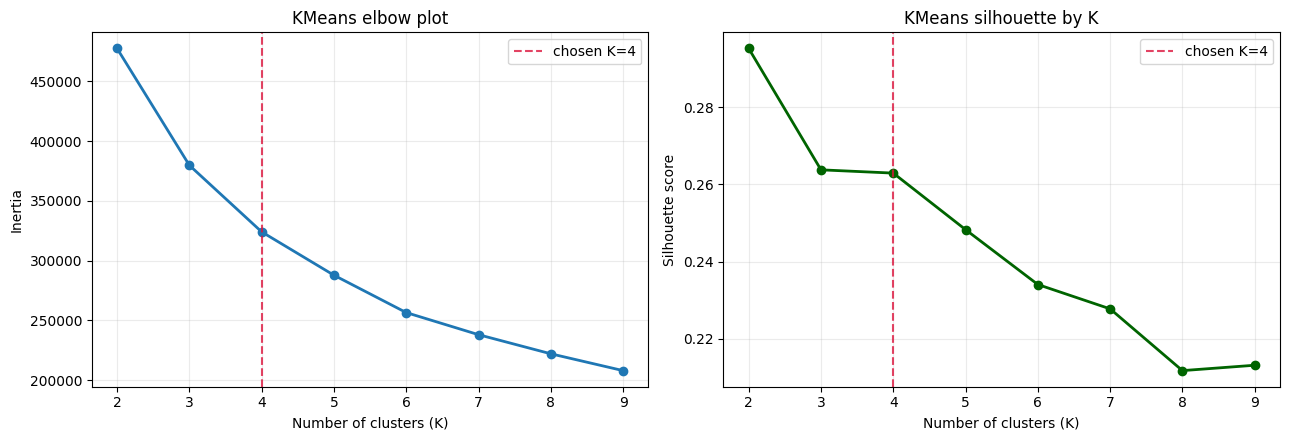

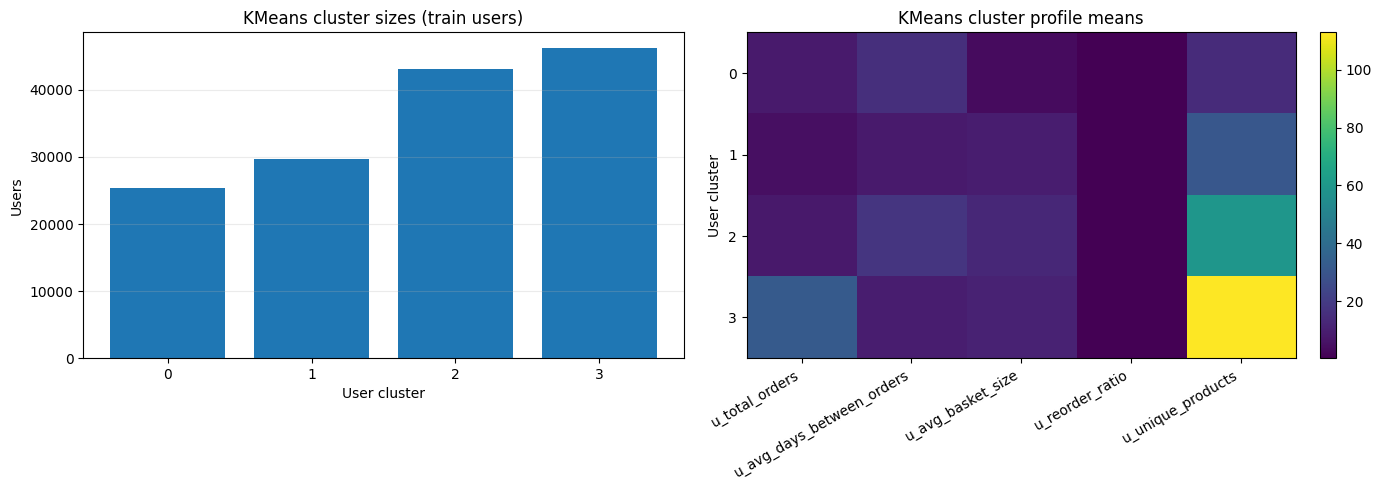

,antecedent,consequent,support,confidence,lift
0,pasta sauce,dry pasta,0.020742,0.314664,4.168569
1,preserved dips spreads,chips pretzels,0.014430,0.425061,2.405012
2,fresh dips tapenades,chips pretzels,0.037053,0.354084,2.003418
3,granola,yogurt,0.016408,0.547278,1.964885
4,cookies cakes,chips pretzels,0.021557,0.345166,1.952962
5,popcorn jerky,chips pretzels,0.016367,0.343410,1.943027
6,fruit vegetable snacks,chips pretzels,0.016706,0.341363,1.931442
7,tofu meat alternatives,soy lactosefree,0.012038,0.339043,1.878893
8,lunch meat,bread,0.036204,0.327916,1.872134
9,pasta sauce,packaged cheese,0.029057,0.440795,1.810248


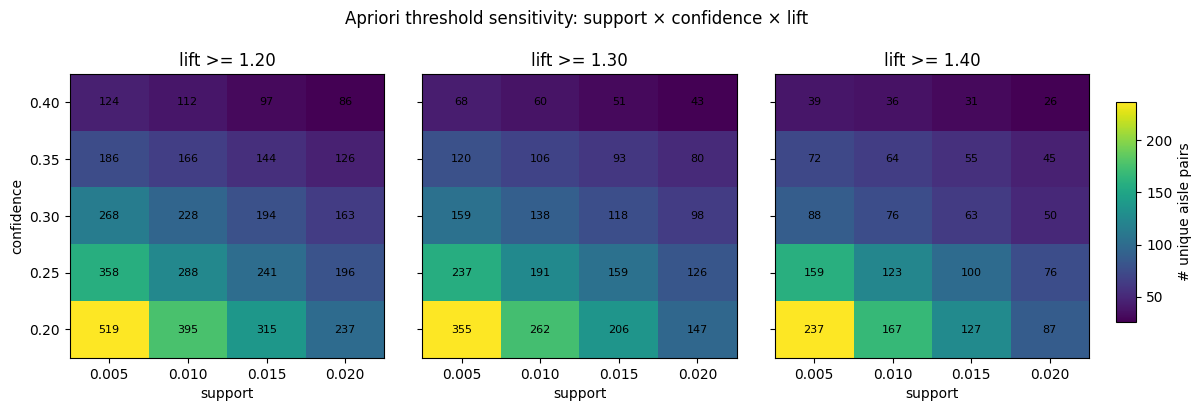

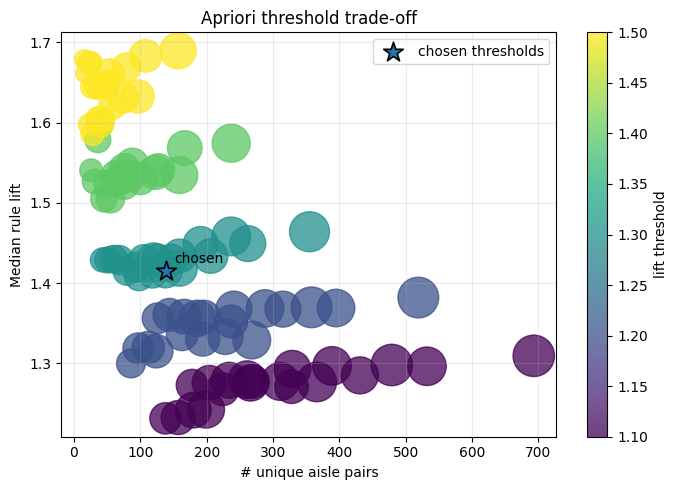

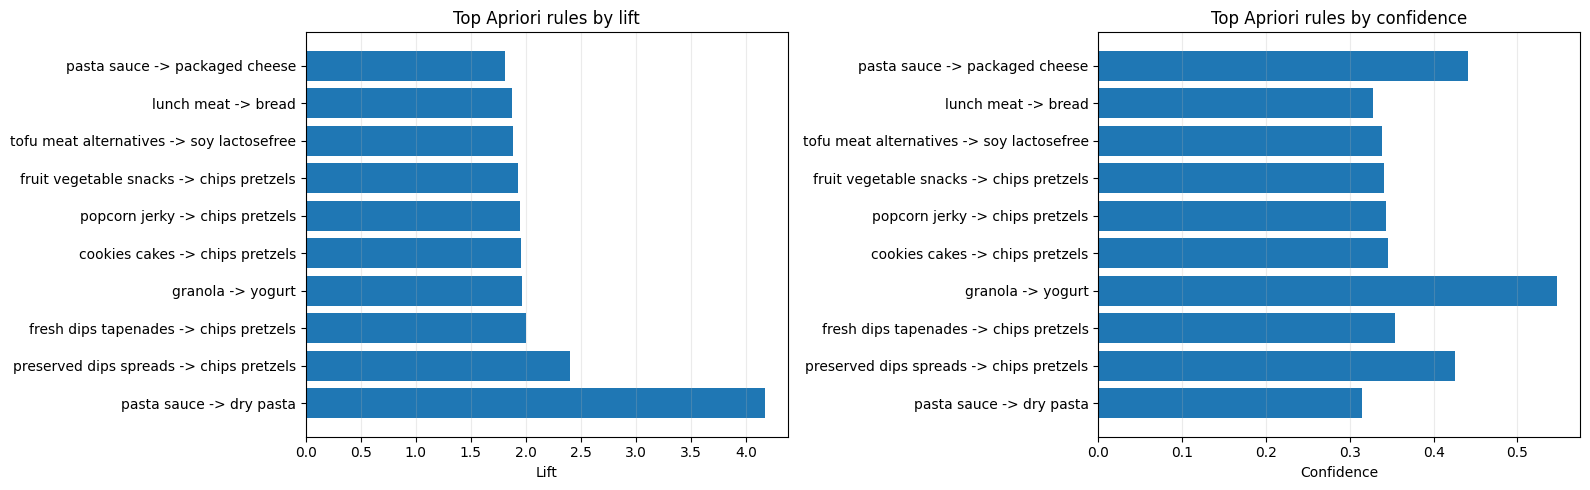

In [7]:
if RUN_KMEANS_APRIORI_DIAGNOSTICS:
    train_history = bundle["history_detail"][bundle["history_detail"]["user_id"].isin(train_users)].copy()
    train_user_feat_diag = compute_user_features(train_history)
    _, _, cluster_feature_cols_diag, _, train_clusters_diag, kmeans_profile = fit_kmeans(train_user_feat_diag)
    kmeans_profile = kmeans_profile.sort_values("user_cluster").reset_index(drop=True)
    kmeans_profile.to_csv(OUTPUT_DIR / "kmeans_cluster_profile.csv", index=False)
    display(kmeans_profile)

    kmeans_diag_features = train_user_feat_diag[cluster_feature_cols_diag].copy()
    for col in ["u_total_orders", "u_avg_basket_size", "u_unique_products"]:
        kmeans_diag_features[col] = np.log1p(kmeans_diag_features[col])
    X_diag = StandardScaler().fit_transform(kmeans_diag_features.fillna(0))
    k_candidates = list(range(2, 10))
    kmeans_diag_rows = []
    for k in k_candidates:
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
        labels = km.fit_predict(X_diag)
        sil = silhouette_score(X_diag, labels) if len(np.unique(labels)) > 1 else np.nan
        kmeans_diag_rows.append({
            "k": k,
            "inertia": float(km.inertia_),
            "silhouette": float(sil),
        })
    kmeans_diag_df = pd.DataFrame(kmeans_diag_rows)
    kmeans_diag_df.to_csv(OUTPUT_DIR / "kmeans_elbow_summary.csv", index=False)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].plot(kmeans_diag_df["k"], kmeans_diag_df["inertia"], marker="o", linewidth=2)
    axes[0].axvline(KMEANS_N_CLUSTERS, color="crimson", linestyle="--", alpha=0.8, label=f"chosen K={KMEANS_N_CLUSTERS}")
    axes[0].set_title("KMeans elbow plot")
    axes[0].set_xlabel("Number of clusters (K)")
    axes[0].set_ylabel("Inertia")
    axes[0].set_xticks(k_candidates)
    axes[0].grid(alpha=0.25)
    axes[0].legend()

    axes[1].plot(kmeans_diag_df["k"], kmeans_diag_df["silhouette"], marker="o", linewidth=2, color="darkgreen")
    axes[1].axvline(KMEANS_N_CLUSTERS, color="crimson", linestyle="--", alpha=0.8, label=f"chosen K={KMEANS_N_CLUSTERS}")
    axes[1].set_title("KMeans silhouette by K")
    axes[1].set_xlabel("Number of clusters (K)")
    axes[1].set_ylabel("Silhouette score")
    axes[1].set_xticks(k_candidates)
    axes[1].grid(alpha=0.25)
    axes[1].legend()
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "kmeans_elbow_plot.png", dpi=160, bbox_inches="tight")
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].bar(kmeans_profile["user_cluster"].astype(str), kmeans_profile["n_users"])
    axes[0].set_title("KMeans cluster sizes (train users)")
    axes[0].set_xlabel("User cluster")
    axes[0].set_ylabel("Users")
    axes[0].grid(axis="y", alpha=0.25)

    heatmap_cols = ["u_total_orders", "u_avg_days_between_orders", "u_avg_basket_size", "u_reorder_ratio", "u_unique_products"]
    im = axes[1].imshow(kmeans_profile[heatmap_cols].to_numpy(), aspect="auto")
    axes[1].set_title("KMeans cluster profile means")
    axes[1].set_xticks(np.arange(len(heatmap_cols)))
    axes[1].set_xticklabels(heatmap_cols, rotation=30, ha="right")
    axes[1].set_yticks(np.arange(len(kmeans_profile)))
    axes[1].set_yticklabels(kmeans_profile["user_cluster"].astype(str))
    axes[1].set_ylabel("User cluster")
    fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "kmeans_diagnostics.png", dpi=160, bbox_inches="tight")
    plt.show()

    apriori_rules, _ = build_apriori_artifacts(train_history)
    if apriori_rules.empty:
        apriori_top = pd.DataFrame(columns=["antecedent", "consequent", "support", "confidence", "lift"])
    else:
        apriori_top = apriori_rules.sort_values(["lift", "confidence", "support"], ascending=[False, False, False]).head(20).reset_index(drop=True)
    apriori_top.to_csv(OUTPUT_DIR / "apriori_top_rules.csv", index=False)
    display(apriori_top)

    basket_aisles_diag = (
        train_history.groupby("order_id")["aisle_name"]
        .apply(lambda x: sorted(set(x.dropna().astype(str))))
        .reset_index(name="aisle_basket")
    )
    basket_aisles_diag = basket_aisles_diag[basket_aisles_diag["aisle_basket"].str.len() >= 2].copy()
    single_counts_diag, pair_counts_diag = {}, {}
    for basket in basket_aisles_diag["aisle_basket"]:
        for item in basket:
            single_counts_diag[item] = single_counts_diag.get(item, 0) + 1
        for i in range(len(basket)):
            for j in range(i + 1, len(basket)):
                pair = (basket[i], basket[j])
                pair_counts_diag[pair] = pair_counts_diag.get(pair, 0) + 1

    support_grid = [0.005, 0.01, 0.015, 0.02]
    confidence_grid = [0.20, 0.25, 0.30, 0.35, 0.40]
    lift_grid_all = [1.10, 1.20, 1.30, 1.40, 1.50]
    lift_grid_heatmap = [1.20, 1.30, 1.40]

    threshold_rows = []
    for cur_lift in lift_grid_all:
        for cur_support in support_grid:
            for cur_confidence in confidence_grid:
                rules_tmp = build_aisle_rules(
                    single_counts=single_counts_diag,
                    pair_counts=pair_counts_diag,
                    n_baskets=max(len(basket_aisles_diag), 1),
                    min_support=cur_support,
                    min_confidence=cur_confidence,
                    min_lift=cur_lift,
                )
                if len(rules_tmp) > 0:
                    median_lift_tmp = float(rules_tmp["lift"].median())
                    covered_aisles_tmp = int(pd.unique(pd.concat([rules_tmp["antecedent"], rules_tmp["consequent"]], ignore_index=True)).shape[0])
                    unique_pairs_tmp = int(rules_tmp[["antecedent", "consequent"]].drop_duplicates().shape[0])
                else:
                    median_lift_tmp = np.nan
                    covered_aisles_tmp = 0
                    unique_pairs_tmp = 0
                threshold_rows.append({
                    "support": cur_support,
                    "confidence": cur_confidence,
                    "lift": cur_lift,
                    "n_rules": int(len(rules_tmp)),
                    "n_unique_pairs": unique_pairs_tmp,
                    "median_rule_lift": median_lift_tmp,
                    "covered_aisles": covered_aisles_tmp,
                })

    apriori_threshold_df = pd.DataFrame(threshold_rows)
    apriori_threshold_df.to_csv(OUTPUT_DIR / "apriori_threshold_sensitivity.csv", index=False)

    fig, axes = plt.subplots(1, len(lift_grid_heatmap), figsize=(4.5 * len(lift_grid_heatmap), 4), sharey=True)
    if len(lift_grid_heatmap) == 1:
        axes = [axes]
    for ax, cur_lift in zip(axes, lift_grid_heatmap):
        heat = (
            apriori_threshold_df[apriori_threshold_df["lift"] == cur_lift]
            .pivot(index="confidence", columns="support", values="n_unique_pairs")
            .sort_index(ascending=False)
        )
        im = ax.imshow(heat.values, aspect="auto")
        ax.set_title(f"lift >= {cur_lift:.2f}")
        ax.set_xlabel("support")
        ax.set_xticks(range(len(heat.columns)))
        ax.set_xticklabels([f"{v:.3f}" for v in heat.columns])
        ax.set_yticks(range(len(heat.index)))
        ax.set_yticklabels([f"{v:.2f}" for v in heat.index])
        if ax is axes[0]:
            ax.set_ylabel("confidence")
        for i in range(heat.shape[0]):
            for j in range(heat.shape[1]):
                val = heat.values[i, j]
                txt = "NA" if pd.isna(val) else str(int(val))
                ax.text(j, i, txt, ha="center", va="center", fontsize=8)
    fig.subplots_adjust(right=0.88, top=0.82, wspace=0.12)
    cbar_ax = fig.add_axes([0.90, 0.20, 0.015, 0.55])
    cbar = fig.colorbar(im, cax=cbar_ax)
    cbar.set_label("# unique aisle pairs")
    fig.suptitle("Apriori threshold sensitivity: support × confidence × lift")
    fig.savefig(OUTPUT_DIR / "apriori_threshold_heatmap.png", dpi=160, bbox_inches="tight")
    plt.show()

    plot_df = apriori_threshold_df[apriori_threshold_df["n_unique_pairs"] > 0].copy()
    if len(plot_df) > 0:
        plt.figure(figsize=(7, 5))
        scatter = plt.scatter(
            plot_df["n_unique_pairs"],
            plot_df["median_rule_lift"],
            s=plot_df["covered_aisles"] * 10,
            c=plot_df["lift"],
            alpha=0.75,
        )
        chosen_mask = (
            (plot_df["support"] == 0.01)
            & (plot_df["confidence"] == 0.30)
            & (plot_df["lift"] == 1.30)
        )
        chosen_df = plot_df[chosen_mask]
        if len(chosen_df) > 0:
            plt.scatter(
                chosen_df["n_unique_pairs"],
                chosen_df["median_rule_lift"],
                s=220,
                marker="*",
                edgecolors="black",
                linewidths=1.2,
                label="chosen thresholds",
            )
            for _, row in chosen_df.iterrows():
                plt.annotate("chosen", (row["n_unique_pairs"], row["median_rule_lift"]), xytext=(6, 6), textcoords="offset points")
        cbar = plt.colorbar(scatter)
        cbar.set_label("lift threshold")
        plt.title("Apriori threshold trade-off")
        plt.xlabel("# unique aisle pairs")
        plt.ylabel("Median rule lift")
        plt.grid(alpha=0.25)
        plt.legend()
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "apriori_threshold_tradeoff.png", dpi=160, bbox_inches="tight")
        plt.show()

    if not apriori_top.empty:
        plot_rules = apriori_top.head(10).copy()
        plot_rules["rule_label"] = plot_rules["antecedent"].astype(str) + " -> " + plot_rules["consequent"].astype(str)
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))
        axes[0].barh(plot_rules["rule_label"], plot_rules["lift"])
        axes[0].set_title("Top Apriori rules by lift")
        axes[0].set_xlabel("Lift")
        axes[0].grid(axis="x", alpha=0.25)

        axes[1].barh(plot_rules["rule_label"], plot_rules["confidence"])
        axes[1].set_title("Top Apriori rules by confidence")
        axes[1].set_xlabel("Confidence")
        axes[1].grid(axis="x", alpha=0.25)
        fig.tight_layout()
        fig.savefig(OUTPUT_DIR / "apriori_rules.png", dpi=160, bbox_inches="tight")
        plt.show()


# 3. Modeling Approach

## Overall Framework

We formulate the problem as binary classification at the `(user, product)` level:

`label = 1` if the product appears in the user's target order, and `label = 0` otherwise.

The model outputs a probability score for each candidate product. The final recommendation list is created by ranking candidate products by predicted probability and selecting the top products for each user.

Although the model is trained as a classifier, the final business objective is ranking and recommendation.

## Feature Engineering

The final feature system contains several groups of predictors.

### User-Product Interaction Features

These are the most important features because they directly describe the relationship between a user and a product:

- `up_buy_cnt`: how many times the user previously bought the product.
- `up_freq`: purchase frequency within the user's history.
- `up_reorder_ratio`: user-product reorder tendency.
- `up_orders_since_last`: number of orders since the user last bought the product.
- `up_days_since_last`: number of days since the user last bought the product.
- `up_first_order` and `up_last_order`: first and last historical purchase positions.
- `up_avg_cart_order`: average add-to-cart position for the user-product pair.

These features capture habit strength and recency, which are central to grocery reorder behavior.

### User-Level Features

User-level features describe overall shopping behavior:

- total historical orders.
- total purchased items.
- average basket size.
- average days between orders.
- user reorder ratio.
- number of unique products purchased.

These features help distinguish heavy users, light users, routine replenishment users, and exploratory shoppers.

### Product-Level Features

Product-level features describe population-level product behavior:

- total product purchases.
- number of unique users buying the product.
- product reorder ratio.
- average cart position.

These features help identify popular and sticky products.

### KMeans User Segmentation Features

We apply KMeans clustering to five user behavioral variables:

- historical order count.
- average days between orders.
- average basket size.
- reorder ratio.
- number of unique products.

We evaluate `K = 2` through `K = 9`. The silhouette score is highest at `K = 2`, but `K = 4` provides a better balance between statistical compactness and business interpretability. The final four clusters represent different shopping styles:

- Cluster 0: light, small-basket users.
- Cluster 1: low-reorder exploratory users.
- Cluster 2: broader-basket users with moderate reorder behavior.
- Cluster 3: high-activity, high-reorder core users.

The cluster labels and cluster-product target-rate features are used to add segment-level context to the model.

### Apriori Association Features

We use Apriori-style association analysis at the aisle level rather than the product level. Product-level combinations are too sparse, while aisle-level rules are more stable and interpretable.

The final thresholds are:

- support >= 0.01.
- confidence >= 0.30.
- lift >= 1.30.

This setting produces 138 aisle-level association pairs, balancing rule coverage and rule quality. The resulting `apriori_rule_hits` feature indicates whether a candidate product's aisle is supported by strong co-purchase patterns from the user's recent basket context.

### ALS Similarity Features

We also test collaborative-filtering-style features based on Alternating Least Squares. ALS factorizes the historical user-item interaction matrix into latent user and product vectors. From these vectors, we construct:

- `als_dot`: raw latent user-product affinity.
- `als_cos`: normalized cosine similarity between user and product embeddings.

ALS is not used as a standalone final recommender. Instead, it is tested as an auxiliary feature source.


In [8]:
def build_model_and_space(model_name: str):
    if model_name == "LogisticRegression_SAGA":
        estimator = Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                solver="saga",
                class_weight="balanced",
                random_state=RANDOM_STATE,
            )),
        ])
        space = {
            "model__C": [0.01, 0.03, 0.1, 0.3, 1.0, 3.0],
            "model__max_iter": [150, 300, 500, 800],
        }
        return estimator, space, False

    if model_name == "LightGBM":
        if not HAS_LIGHTGBM:
            raise RuntimeError("LightGBM is not installed.")
        estimator = lgb.LGBMClassifier(
            objective="binary",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=-1,
        )
        space = {
            "num_leaves": [31, 63, 127],
            "learning_rate": [0.01, 0.03, 0.05, 0.1],
            "n_estimators": [300, 500, 800, 1000],
            "min_child_samples": [20, 30, 50, 100],
            "subsample": [0.7, 0.8, 1.0],
            "colsample_bytree": [0.7, 0.8, 1.0],
            "reg_lambda": [0.0, 1.0, 3.0, 5.0],
        }
        return estimator, space, False

    if model_name == "MLP":
        estimator = Pipeline([
            ("scaler", StandardScaler()),
            ("model", MLPClassifier(
                random_state=RANDOM_STATE,
                early_stopping=True,
                validation_fraction=0.1,
                n_iter_no_change=8,
                max_iter=100,
                verbose=False,
            )),
        ])
        space = {
            "model__hidden_layer_sizes": [(64,), (128,), (128, 64), (256, 128)],
            "model__alpha": [1e-4, 3e-4, 1e-3, 3e-3],
            "model__learning_rate_init": [3e-4, 1e-3, 3e-3],
            "model__batch_size": [256, 512, 1024],
        }
        return estimator, space, False

    if model_name == "CatBoost":
        if not HAS_CATBOOST:
            raise RuntimeError("CatBoost is not installed.")
        estimator = CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="AUC",
            random_seed=RANDOM_STATE,
            verbose=False,
            allow_writing_files=False,
            task_type="GPU" if USE_GPU_FOR_CATBOOST else "CPU",
            devices=CATBOOST_GPU_DEVICE if USE_GPU_FOR_CATBOOST else None,
        )
        space = {
            "depth": [6, 8, 10],
            "learning_rate": [0.02, 0.03, 0.05, 0.08],
            "iterations": [400, 700, 1000, 1200],
            "l2_leaf_reg": [3.0, 5.0, 7.0, 9.0],
        }
        return estimator, space, True

    raise ValueError(model_name)


def dedupe_feature_frame(df: pd.DataFrame) -> pd.DataFrame:
    return df.loc[:, ~df.columns.duplicated()].copy()


def fit_estimator(estimator, X_train, y_train, is_catboost: bool, params: dict):
    X_train = dedupe_feature_frame(X_train)
    model = clone(estimator)
    model.set_params(**params)
    if is_catboost:
        pos_rate = float(np.mean(y_train))
        model.set_params(scale_pos_weight=(1.0 - pos_rate) / max(pos_rate, 1e-6))
        cat_cols = [c for c in CATBOOST_CAT_COLS if c in X_train.columns]
        cat_idx = [X_train.columns.get_loc(col) for col in cat_cols]
        model.fit(X_train, y_train, cat_features=cat_idx)
    else:
        model.fit(X_train, y_train)
    return model


def sample_param_dicts(space: dict, n_iter: int):
    n_total = 1
    for values in space.values():
        n_total *= len(values)
    actual_n = min(n_iter, n_total)
    return list(ParameterSampler(space, n_iter=actual_n, random_state=RANDOM_STATE))


def fit_and_predict_for_split(model_name: str, stage_name: str, fit_users: np.ndarray, eval_users: np.ndarray, params: dict, split_name: str):
    estimator, space, is_catboost = build_model_and_space(model_name)
    train_df, eval_df, features = build_fold_feature_tables(fit_users, eval_users, stage_name)
    use_cols = features + (CATBOOST_CAT_COLS if is_catboost else [])
    X_train = dedupe_feature_frame(train_df[use_cols])
    X_eval = dedupe_feature_frame(eval_df[use_cols])
    final_model = fit_estimator(
        estimator,
        X_train,
        train_df["label"].to_numpy(),
        is_catboost,
        params,
    )
    eval_prob = final_model.predict_proba(X_eval)[:, 1]
    pred_frame = eval_df[["user_id", "product_id", "label", "u_avg_basket_size", "user_cluster"]].copy()
    pred_frame["prob"] = eval_prob
    pred_frame["model"] = model_name
    pred_frame["stage"] = stage_name
    pred_frame["split"] = split_name
    return pred_frame


def tune_on_validation_and_eval_test(model_name: str, stage_name: str):
    estimator, space, is_catboost = build_model_and_space(model_name)
    train_df, val_df, features = build_fold_feature_tables(train_users, val_users, stage_name)
    use_cols = features + (CATBOOST_CAT_COLS if is_catboost else [])
    X_train = dedupe_feature_frame(train_df[use_cols])
    X_val = dedupe_feature_frame(val_df[use_cols])
    param_candidates = sample_param_dicts(space, N_ITER_SEARCH[model_name])

    tuning_rows = []
    for rank_idx, params in enumerate(param_candidates, start=1):
        model = fit_estimator(estimator, X_train, train_df["label"].to_numpy(), is_catboost, params)
        val_prob = model.predict_proba(X_val)[:, 1]
        y_val = val_df["label"].to_numpy()
        val_auc = roc_auc_score(y_val, val_prob) if len(np.unique(y_val)) > 1 else np.nan
        val_pr_auc = average_precision_score(y_val, val_prob) if len(np.unique(y_val)) > 1 else np.nan
        tuning_rows.append({
            "model": model_name,
            "stage": stage_name,
            "candidate_rank": rank_idx,
            "validation_auc": float(val_auc),
            "validation_pr_auc": float(val_pr_auc),
            "params": str(params),
        })

    tuning_df = pd.DataFrame(tuning_rows).sort_values(
        ["validation_auc", "validation_pr_auc"],
        ascending=[False, False],
    ).reset_index(drop=True)
    best_params = ast.literal_eval(tuning_df.iloc[0]["params"])

    best_model = fit_estimator(estimator, X_train, train_df["label"].to_numpy(), is_catboost, best_params)
    val_prob = best_model.predict_proba(X_val)[:, 1]
    val_pred = val_df[["user_id", "product_id", "label", "u_avg_basket_size", "user_cluster"]].copy()
    val_pred["prob"] = val_prob
    val_pred["model"] = model_name
    val_pred["stage"] = stage_name
    val_pred["split"] = "validation"

    test_pred = fit_and_predict_for_split(model_name, stage_name, train_users, test_users, best_params, "test")
    return val_pred, test_pred, tuning_df, best_params


MODEL_NAMES = ["LogisticRegression_SAGA", "LightGBM", "MLP", "CatBoost"]


In [9]:
main_pred_store = {}
main_tuning_store = {}
final_stage = "plus_als"

if RUN_MAIN_TUNING:
    for model_name in MODEL_NAMES:
        val_pred, test_pred, tuning_df, modal_params = tune_on_validation_and_eval_test(model_name, final_stage)
        main_pred_store[model_name] = {
            "validation": val_pred,
            "test": test_pred,
        }
        main_tuning_store[model_name] = {
            "tuning": tuning_df,
            "modal_best_params": modal_params,
        }

    main_summary_rows = []
    for model_name, split_map in main_pred_store.items():
        for split_name, pred_df in split_map.items():
            row = {"model": model_name, "stage": final_stage, "split": split_name}
            row.update(evaluate_prediction_frame(pred_df))
            row["modal_best_params"] = str(main_tuning_store[model_name]["modal_best_params"])
            main_summary_rows.append(row)

    main_summary = pd.DataFrame(main_summary_rows).sort_values(["split", "pr_auc"], ascending=[True, False]).reset_index(drop=True)
    main_tuning_detail = pd.concat(
        [v["tuning"] for v in main_tuning_store.values()],
        ignore_index=True,
    ).sort_values(["model", "validation_auc", "validation_pr_auc"], ascending=[True, False, False]).reset_index(drop=True)
    main_summary.to_csv(OUTPUT_DIR / "main_model_summary.csv", index=False)
    main_tuning_detail.to_csv(OUTPUT_DIR / "main_tuning_detail.csv", index=False)
    pd.concat(
        [df for split_map in main_pred_store.values() for df in split_map.values()],
        ignore_index=True,
    ).to_parquet(OUTPUT_DIR / "main_predictions.parquet", index=False)
    with (OUTPUT_DIR / "main_modal_params.json").open("w", encoding="utf-8") as fh:
        json.dump({k: v["modal_best_params"] for k, v in main_tuning_store.items()}, fh, indent=2)

    display(main_summary)
    display(main_tuning_detail)


  0%|          | 0/15 [00:00<?, ?it/s]

/venv/main/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/venv/main/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/venv/main/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/venv/main/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


  0%|          | 0/15 [00:00<?, ?it/s]

/venv/main/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


  0%|          | 0/15 [00:00<?, ?it/s]

...

Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


  0%|          | 0/15 [00:00<?, ?it/s]

Default metric period is 5 because AUC is/are not implemented for GPU


,model,stage,split,auc,pr_auc,logloss,precision@11,recall@11,f1@11,hit@11,avg_k@11,precision@dynamic_k,recall@dynamic_k,f1@dynamic_k,hit@dynamic_k,avg_k@dynamic_k,modal_best_params
0,LightGBM,plus_als,test,0.831461,0.417650,0.248845,0.298596,0.573810,0.345304,0.877796,11.0,0.330528,0.516641,0.372787,0.840844,9.871686,"{'subsample': 1.0, 'reg_lambda': 3.0, 'num_lea..."
1,CatBoost,plus_als,test,0.832148,0.416664,0.543755,0.299120,0.575332,0.345977,0.878702,11.0,0.330396,0.516523,0.372579,0.840456,9.871686,"{'learning_rate': 0.03, 'l2_leaf_reg': 3.0, 'i..."
2,MLP,plus_als,test,0.810751,0.394816,0.260764,0.290682,0.564002,0.337451,0.874467,11.0,0.321445,0.504463,0.363119,0.836221,9.871686,"{'model__learning_rate_init': 0.001, 'model__h..."
3,LogisticRegression_SAGA,plus_als,test,0.812705,0.352413,0.670847,0.286846,0.559394,0.333664,0.875081,11.0,0.316678,0.497000,0.357777,0.834120,9.871686,"{'model__max_iter': 300, 'model__C': 3.0}"
4,LightGBM,plus_als,validation,0.831310,0.418410,0.250606,0.299668,0.574611,0.346492,0.878116,11.0,0.330593,0.518430,0.372905,0.841583,9.965795,"{'subsample': 1.0, 'reg_lambda': 3.0, 'num_lea..."
5,CatBoost,plus_als,validation,0.832225,0.418135,0.549052,0.299597,0.574694,0.346475,0.878083,11.0,0.331011,0.518958,0.373417,0.842003,9.965795,"{'learning_rate': 0.03, 'l2_leaf_reg': 3.0, 'i..."
6,MLP,plus_als,validation,0.811173,0.397604,0.262298,0.291891,0.563453,0.338416,0.874236,11.0,0.321844,0.506123,0.363481,0.837542,9.965795,"{'model__learning_rate_init': 0.001, 'model__h..."
7,LogisticRegression_SAGA,plus_als,validation,0.812702,0.350769,0.677447,0.288240,0.558241,0.334541,0.873622,11.0,0.317007,0.498158,0.357949,0.834115,9.965795,"{'model__max_iter': 300, 'model__C': 3.0}"


,model,stage,candidate_rank,validation_auc,validation_pr_auc,params
0,CatBoost,plus_als,5,0.832177,0.418141,"{'learning_rate': 0.03, 'l2_leaf_reg': 3.0, 'i..."
1,CatBoost,plus_als,8,0.832173,0.417408,"{'learning_rate': 0.05, 'l2_leaf_reg': 3.0, 'i..."
2,CatBoost,plus_als,1,0.832112,0.416969,"{'learning_rate': 0.03, 'l2_leaf_reg': 9.0, 'i..."
3,CatBoost,plus_als,2,0.832101,0.415531,"{'learning_rate': 0.02, 'l2_leaf_reg': 7.0, 'i..."
4,CatBoost,plus_als,7,0.831959,0.417062,"{'learning_rate': 0.08, 'l2_leaf_reg': 9.0, 'i..."
5,CatBoost,plus_als,9,0.831669,0.414325,"{'learning_rate': 0.02, 'l2_leaf_reg': 3.0, 'i..."
6,CatBoost,plus_als,3,0.831551,0.413898,"{'learning_rate': 0.02, 'l2_leaf_reg': 9.0, 'i..."
7,CatBoost,plus_als,6,0.831527,0.418061,"{'learning_rate': 0.03, 'l2_leaf_reg': 3.0, 'i..."
8,CatBoost,plus_als,10,0.831404,0.413558,"{'learning_rate': 0.03, 'l2_leaf_reg': 7.0, 'i..."
9,CatBoost,plus_als,4,0.830931,0.417150,"{'learning_rate': 0.08, 'l2_leaf_reg': 9.0, 'i..."


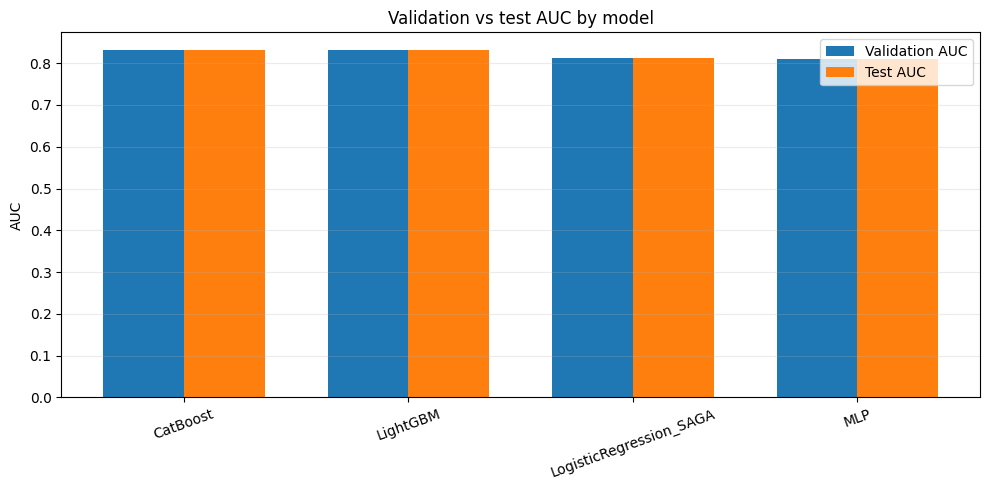

split,model,validation,test,auc_gap_validation_minus_test
0,MLP,0.811173,0.810751,0.000422
1,CatBoost,0.832225,0.832148,0.000077
2,LogisticRegression_SAGA,0.812702,0.812705,-0.000004
3,LightGBM,0.831310,0.831461,-0.000151


In [10]:
if RUN_MAIN_TUNING:
    plot_summary = main_summary.copy()
else:
    plot_summary = pd.read_csv(OUTPUT_DIR / "main_model_summary.csv")

if not plot_summary.empty:
    plot_df = (
        plot_summary.pivot(index="model", columns="split", values="auc")
        .reset_index()
        .dropna(subset=["validation", "test"], how="any")
    )
    model_order = plot_df["model"].tolist()
    x = np.arange(len(model_order))
    width = 0.36

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - width / 2, plot_df["validation"], width=width, label="Validation AUC")
    ax.bar(x + width / 2, plot_df["test"], width=width, label="Test AUC")
    ax.set_xticks(x)
    ax.set_xticklabels(model_order, rotation=20)
    ax.set_ylabel("AUC")
    ax.set_title("Validation vs test AUC by model")
    ax.grid(axis="y", alpha=0.25)
    ax.legend()
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "main_validation_vs_test_auc.png", dpi=160, bbox_inches="tight")
    plt.show()

    plot_df["auc_gap_validation_minus_test"] = plot_df["validation"] - plot_df["test"]
    display(plot_df[["model", "validation", "test", "auc_gap_validation_minus_test"]].sort_values(
        "auc_gap_validation_minus_test",
        ascending=False,
    ).reset_index(drop=True))


In [11]:
ablation_store = {}

if RUN_ABLATION:
    if not main_tuning_store:
        main_modal_params = json.loads((OUTPUT_DIR / "main_modal_params.json").read_text())
    else:
        main_modal_params = {k: v["modal_best_params"] for k, v in main_tuning_store.items()}

    ablation_rows = []
    for model_name in ABLATION_MODELS:
        fixed_params = main_modal_params[model_name]
        for stage_name in FEATURE_STAGES:
            val_pred = fit_and_predict_for_split(model_name, stage_name, train_users, val_users, fixed_params, "validation")
            test_pred = fit_and_predict_for_split(model_name, stage_name, train_users, test_users, fixed_params, "test")
            ablation_store[(model_name, stage_name)] = {
                "validation": val_pred,
                "test": test_pred,
                "fixed_params": fixed_params,
            }
            for split_name, pred_df in [("validation", val_pred), ("test", test_pred)]:
                row = {
                    "model": model_name,
                    "stage": stage_name,
                    "split": split_name,
                    "n_features": len(FEATURE_STAGES[stage_name]),
                }
                row.update(evaluate_prediction_frame(pred_df))
                row["fixed_params"] = str(fixed_params)
                ablation_rows.append(row)

    ablation_summary = pd.DataFrame(ablation_rows)
    ablation_summary["stage"] = pd.Categorical(
        ablation_summary["stage"],
        categories=list(FEATURE_STAGES.keys()),
        ordered=True,
    )
    ablation_summary = ablation_summary.sort_values(["split", "model", "stage"]).reset_index(drop=True)
    ablation_summary.to_csv(OUTPUT_DIR / "ablation_summary.csv", index=False)
    ablation_summary_test = ablation_summary[ablation_summary["split"] == "test"].copy().reset_index(drop=True)
    ablation_summary_test.to_csv(OUTPUT_DIR / "ablation_summary_test.csv", index=False)
    display(ablation_summary)


  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


  0%|          | 0/15 [00:00<?, ?it/s]

Default metric period is 5 because AUC is/are not implemented for GPU


  0%|          | 0/15 [00:00<?, ?it/s]

Default metric period is 5 because AUC is/are not implemented for GPU


,model,stage,split,n_features,auc,pr_auc,logloss,precision@11,recall@11,f1@11,hit@11,avg_k@11,precision@dynamic_k,recall@dynamic_k,f1@dynamic_k,hit@dynamic_k,avg_k@dynamic_k,fixed_params
0,CatBoost,interaction_only,test,8,0.826913,0.408693,0.505496,0.295922,0.567948,0.342074,0.874693,11.0,0.327454,0.510078,0.368930,0.837515,9.871686,"{'learning_rate': 0.03, 'l2_leaf_reg': 3.0, 'i..."
1,CatBoost,plus_user_product,test,18,0.833186,0.417726,0.497530,0.299164,0.575791,0.346097,0.879187,11.0,0.331008,0.517516,0.373251,0.841976,9.871686,"{'learning_rate': 0.03, 'l2_leaf_reg': 3.0, 'i..."
2,CatBoost,plus_kmeans,test,22,0.833723,0.418207,0.497537,0.299405,0.576002,0.346346,0.879187,11.0,0.331048,0.518028,0.373388,0.841911,9.871686,"{'learning_rate': 0.03, 'l2_leaf_reg': 3.0, 'i..."
3,CatBoost,plus_apriori,test,23,0.833739,0.418249,0.497495,0.299516,0.576062,0.346431,0.879057,11.0,0.331248,0.518112,0.373553,0.841879,9.871686,"{'learning_rate': 0.03, 'l2_leaf_reg': 3.0, 'i..."
4,CatBoost,plus_als,test,25,0.832173,0.416683,0.543150,0.299175,0.575264,0.346030,0.878637,11.0,0.330513,0.516861,0.372749,0.840489,9.871686,"{'learning_rate': 0.03, 'l2_leaf_reg': 3.0, 'i..."
5,LightGBM,interaction_only,test,8,0.820541,0.402362,0.253089,0.291390,0.556798,0.336275,0.870038,11.0,0.322016,0.498191,0.362051,0.830919,9.871686,"{'subsample': 1.0, 'reg_lambda': 3.0, 'num_lea..."
6,LightGBM,plus_user_product,test,18,0.832248,0.418040,0.247826,0.299064,0.575163,0.345929,0.879219,11.0,0.330369,0.516888,0.372611,0.841297,9.871686,"{'subsample': 1.0, 'reg_lambda': 3.0, 'num_lea..."
7,LightGBM,plus_kmeans,test,22,0.832846,0.418905,0.247540,0.298934,0.575150,0.345841,0.879122,11.0,0.330897,0.517400,0.373182,0.841135,9.871686,"{'subsample': 1.0, 'reg_lambda': 3.0, 'num_lea..."
8,LightGBM,plus_apriori,test,23,0.832880,0.418679,0.247547,0.299155,0.575322,0.346058,0.879025,11.0,0.330782,0.517468,0.373086,0.841523,9.871686,"{'subsample': 1.0, 'reg_lambda': 3.0, 'num_lea..."
9,LightGBM,plus_als,test,25,0.831461,0.417650,0.248845,0.298596,0.573810,0.345304,0.877796,11.0,0.330528,0.516641,0.372787,0.840844,9.871686,"{'subsample': 1.0, 'reg_lambda': 3.0, 'num_lea..."


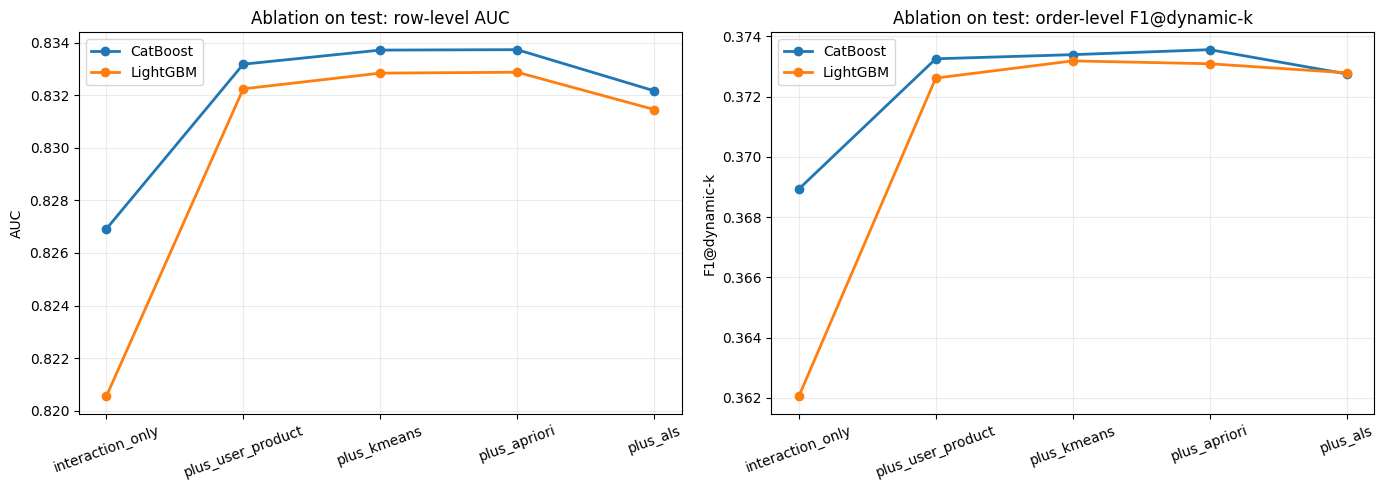

In [12]:
if RUN_ABLATION:
    ablation_plot_df = ablation_summary.copy()
else:
    ablation_plot_df = pd.read_csv(OUTPUT_DIR / "ablation_summary.csv")

if not ablation_plot_df.empty:
    ablation_plot_df = ablation_plot_df[ablation_plot_df["split"] == "test"].copy()
    stage_order = list(FEATURE_STAGES.keys())
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

    for model_name, g in ablation_plot_df.groupby("model"):
        g["stage"] = pd.Categorical(g["stage"], categories=stage_order, ordered=True)
        g = g.sort_values("stage")
        axes[0].plot(g["stage"].astype(str), g["auc"], marker="o", linewidth=2, label=model_name)
        axes[1].plot(g["stage"].astype(str), g["f1@dynamic_k"], marker="o", linewidth=2, label=model_name)

    axes[0].set_title("Ablation on test: row-level AUC")
    axes[0].set_ylabel("AUC")
    axes[0].grid(alpha=0.25)
    axes[1].set_title("Ablation on test: order-level F1@dynamic-k")
    axes[1].set_ylabel("F1@dynamic-k")
    axes[1].grid(alpha=0.25)

    for ax in axes:
        ax.tick_params(axis="x", rotation=20)
        ax.legend()

    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "ablation_curves.png", dpi=160, bbox_inches="tight")
    plt.show()


In [13]:
if RUN_SEGMENT_ANALYSIS:
    if not main_pred_store:
        main_pred_df = pd.read_parquet(OUTPUT_DIR / "main_predictions.parquet")
        segment_input = {
            name: {
                split_name: main_pred_df[(main_pred_df["model"] == name) & (main_pred_df["split"] == split_name)].copy()
                for split_name in sorted(main_pred_df["split"].unique())
            }
            for name in main_pred_df["model"].unique()
        }
    else:
        segment_input = main_pred_store

    segment_rows = []
    for model_name, split_map in segment_input.items():
        for split_name, pred_df in split_map.items():
            fixed_map = make_k_map(pred_df, "fixed_11")
            dynamic_map = make_k_map(pred_df, "rounded_avg_basket")
            base_ranked = pred_df.sort_values(["user_id", "prob", "product_id"], ascending=[True, False, True]).copy()
            base_ranked["rank_within_user"] = base_ranked.groupby("user_id").cumcount() + 1
            base_ranked["pred_k_11"] = base_ranked["user_id"].map(fixed_map).astype(int)
            base_ranked["pred_top_11"] = (base_ranked["rank_within_user"] <= base_ranked["pred_k_11"]).astype(int)
            base_ranked["pred_k_dynamic"] = base_ranked["user_id"].map(dynamic_map).astype(int)
            base_ranked["pred_top_dynamic"] = (base_ranked["rank_within_user"] <= base_ranked["pred_k_dynamic"]).astype(int)

            for segment_value, g in base_ranked.groupby("user_cluster"):
                row = {
                    "model": model_name,
                    "split": split_name,
                    "segment": int(segment_value),
                    "users": int(g["user_id"].nunique()),
                }
                row.update(eval_row_level(g["label"].to_numpy(), g["prob"].to_numpy()))

                per_user_f1_11, per_user_hit_11 = [], []
                per_user_f1_dyn, per_user_hit_dyn, per_user_avgk_dyn = [], [], []
                for _, gu in g.groupby("user_id"):
                    y_true = gu["label"].to_numpy()
                    pred11 = gu["pred_top_11"].to_numpy()
                    predd = gu["pred_top_dynamic"].to_numpy()
                    per_user_f1_11.append(f1_score(y_true, pred11, zero_division=0))
                    per_user_hit_11.append(float((gu.loc[gu["pred_top_11"] == 1, "label"].sum() > 0)))
                    per_user_f1_dyn.append(f1_score(y_true, predd, zero_division=0))
                    per_user_hit_dyn.append(float((gu.loc[gu["pred_top_dynamic"] == 1, "label"].sum() > 0)))
                    per_user_avgk_dyn.append(float(gu["pred_k_dynamic"].iloc[0]))

                row["f1@11"] = float(np.mean(per_user_f1_11))
                row["hit@11"] = float(np.mean(per_user_hit_11))
                row["f1@dynamic_k"] = float(np.mean(per_user_f1_dyn))
                row["hit@dynamic_k"] = float(np.mean(per_user_hit_dyn))
                row["avg_k@dynamic_k"] = float(np.mean(per_user_avgk_dyn))
                row["dynamic_gain_vs_f11"] = row["f1@dynamic_k"] - row["f1@11"]
                segment_rows.append(row)

    segment_summary = pd.DataFrame(segment_rows).sort_values(["split", "model", "segment"]).reset_index(drop=True)
    segment_summary.to_csv(OUTPUT_DIR / "segment_summary.csv", index=False)
    segment_summary_test = segment_summary[segment_summary["split"] == "test"].copy().reset_index(drop=True)
    segment_summary_test.to_csv(OUTPUT_DIR / "segment_summary_test.csv", index=False)
    display(segment_summary)


,model,split,segment,users,auc,pr_auc,logloss,f1@11,hit@11,f1@dynamic_k,hit@dynamic_k,avg_k@dynamic_k,dynamic_gain_vs_f11
0,CatBoost,test,0,5518,0.813907,0.508352,0.662398,0.342073,0.834723,0.424049,0.722363,3.493476,0.081976
1,CatBoost,test,1,6200,0.771977,0.399596,0.711168,0.315765,0.833387,0.331581,0.790645,9.339839,0.015816
2,CatBoost,test,2,9315,0.794678,0.393922,0.654419,0.345057,0.889318,0.353986,0.880408,12.617284,0.008929
3,CatBoost,test,3,9899,0.854245,0.423171,0.453800,0.367941,0.921608,0.387061,0.899889,11.176583,0.019120
4,LightGBM,test,0,5518,0.812827,0.510142,0.340925,0.341786,0.833998,0.424745,0.725263,3.493476,0.082959
5,LightGBM,test,1,6200,0.771183,0.400536,0.336564,0.315205,0.831129,0.332269,0.790645,9.339839,0.017065
6,LightGBM,test,2,9315,0.793696,0.394760,0.299036,0.344122,0.888996,0.354011,0.880086,12.617284,0.009888
7,LightGBM,test,3,9899,0.853663,0.423962,0.203479,0.367229,0.920901,0.386869,0.899788,11.176583,0.019641
8,LogisticRegression_SAGA,test,0,5518,0.803651,0.487648,0.744781,0.340924,0.836173,0.414709,0.713121,3.493476,0.073785
9,LogisticRegression_SAGA,test,1,6200,0.763099,0.380597,0.796217,0.311486,0.828710,0.326383,0.785806,9.339839,0.014897


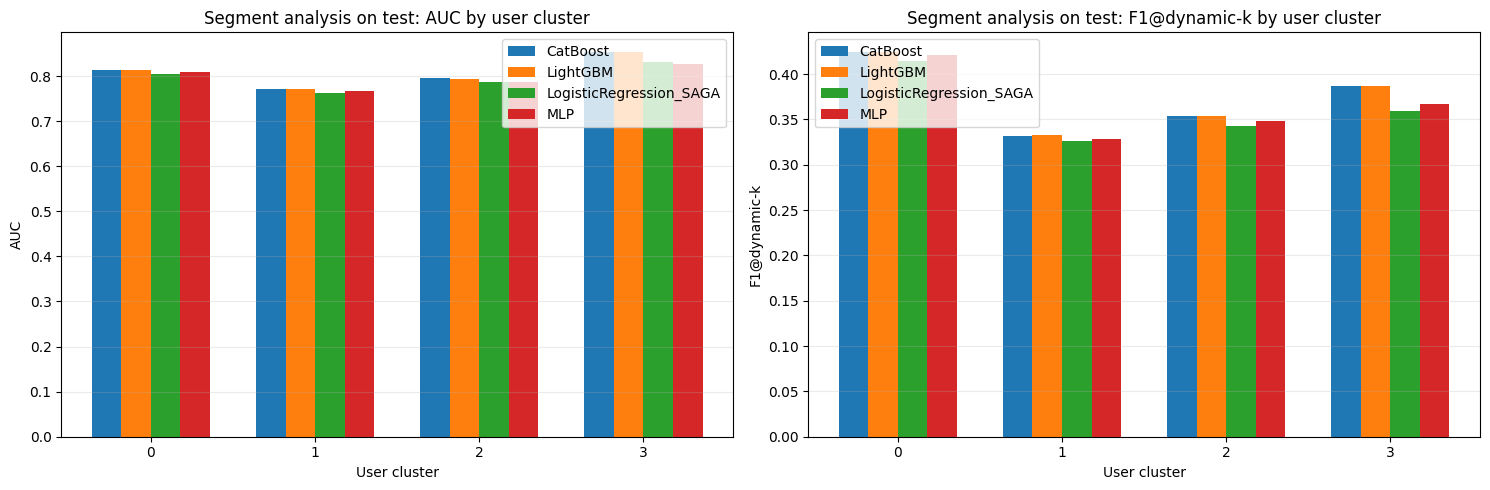

In [14]:
if RUN_SEGMENT_ANALYSIS:
    segment_plot_df = segment_summary.copy()
else:
    segment_plot_df = pd.read_csv(OUTPUT_DIR / "segment_summary.csv")

if not segment_plot_df.empty:
    segment_plot_df = segment_plot_df[segment_plot_df["split"] == "test"].copy()
    model_order = list(segment_plot_df["model"].drop_duplicates())
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    width = 0.18 if len(model_order) >= 4 else 0.25
    segments = sorted(segment_plot_df["segment"].unique())
    x = np.arange(len(segments))

    for i, model_name in enumerate(model_order):
        g = (
            segment_plot_df[segment_plot_df["model"] == model_name]
            .set_index("segment")
            .reindex(segments)
            .reset_index()
        )
        offset = (i - (len(model_order) - 1) / 2) * width
        axes[0].bar(x + offset, g["auc"], width=width, label=model_name)
        axes[1].bar(x + offset, g["f1@dynamic_k"], width=width, label=model_name)

    axes[0].set_title("Segment analysis on test: AUC by user cluster")
    axes[0].set_ylabel("AUC")
    axes[1].set_title("Segment analysis on test: F1@dynamic-k by user cluster")
    axes[1].set_ylabel("F1@dynamic-k")

    for ax in axes:
        ax.set_xticks(x)
        ax.set_xticklabels([str(s) for s in segments])
        ax.set_xlabel("User cluster")
        ax.grid(axis="y", alpha=0.25)
        ax.legend()

    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "segment_analysis_bars.png", dpi=160, bbox_inches="tight")
    plt.show()


In [15]:
if RUN_TOPK_ANALYSIS:
    if not main_pred_store:
        main_pred_df = pd.read_parquet(OUTPUT_DIR / "main_predictions.parquet")
        topk_input = {
            name: {
                split_name: main_pred_df[(main_pred_df["model"] == name) & (main_pred_df["split"] == split_name)].copy()
                for split_name in sorted(main_pred_df["split"].unique())
            }
            for name in main_pred_df["model"].unique()
        }
    else:
        topk_input = main_pred_store

    topk_rows = []
    for model_name, split_map in topk_input.items():
        for split_name, pred_df in split_map.items():
            row_level = eval_row_level(pred_df["label"].to_numpy(), pred_df["prob"].to_numpy())
            for strategy in TOPK_STRATEGIES:
                metrics = eval_order_with_k_map(
                    pred_df[["user_id", "product_id", "label", "u_avg_basket_size", "prob"]].copy(),
                    make_k_map(pred_df, strategy),
                    prefix="strategy",
                )
                topk_rows.append({
                    "model": model_name,
                    "split": split_name,
                    "strategy": strategy,
                    **row_level,
                    "precision": metrics["precision@strategy"],
                    "recall": metrics["recall@strategy"],
                    "f1": metrics["f1@strategy"],
                    "hit": metrics["hit@strategy"],
                    "avg_k": metrics["avg_k@strategy"],
                })

    topk_summary = pd.DataFrame(topk_rows).sort_values(["split", "model", "strategy"]).reset_index(drop=True)
    topk_summary.to_csv(OUTPUT_DIR / "topk_strategy_summary.csv", index=False)
    display(topk_summary)


,model,split,strategy,auc,pr_auc,logloss,precision,recall,f1,hit,avg_k
0,CatBoost,test,ceil_avg_basket,0.832148,0.416664,0.543755,0.321964,0.533583,0.372075,0.848377,10.296489
1,CatBoost,test,fixed_11,0.832148,0.416664,0.543755,0.299120,0.575332,0.345977,0.878702,11.000000
2,CatBoost,test,rounded_avg_basket,0.832148,0.416664,0.543755,0.330396,0.516523,0.372579,0.840456,9.871686
3,LightGBM,test,ceil_avg_basket,0.831461,0.417650,0.248845,0.321931,0.533395,0.372077,0.848345,10.296489
4,LightGBM,test,fixed_11,0.831461,0.417650,0.248845,0.298596,0.573810,0.345304,0.877796,11.000000
5,LightGBM,test,rounded_avg_basket,0.831461,0.417650,0.248845,0.330528,0.516641,0.372787,0.840844,9.871686
6,LogisticRegression_SAGA,test,ceil_avg_basket,0.812705,0.352413,0.670847,0.308408,0.512716,0.356991,0.841459,10.296489
7,LogisticRegression_SAGA,test,fixed_11,0.812705,0.352413,0.670847,0.286846,0.559394,0.333664,0.875081,11.000000
8,LogisticRegression_SAGA,test,rounded_avg_basket,0.812705,0.352413,0.670847,0.316678,0.497000,0.357777,0.834120,9.871686
9,MLP,test,ceil_avg_basket,0.810751,0.394816,0.260764,0.312751,0.520459,0.362165,0.843819,10.296489


## Models

We compare four models:

- Logistic Regression with SAGA: a linear baseline that tests whether engineered features alone provide useful signal.
- LightGBM: a gradient-boosted decision tree model that captures nonlinear relationships and feature interactions efficiently.
- MLP: a feed-forward neural network that learns nonlinear transformations of the feature table.
- CatBoost: a boosted tree model that is strong for tabular prediction and robust to complex feature interactions.

The final tuned model settings include:

- Logistic Regression: `C = 3.0`, `max_iter = 300`.
- LightGBM: `num_leaves = 127`, `learning_rate = 0.03`, `n_estimators = 500`, `min_child_samples = 30`, `reg_lambda = 3.0`, `colsample_bytree = 0.8`, `subsample = 1.0`.
- MLP: hidden layers `(128, 64)`, learning rate `0.001`, batch size `512`, alpha `0.0001`.
- CatBoost: depth `8`, learning rate `0.03`, `l2_leaf_reg = 3.0`, `iterations = 1200`.

## Validation and Evaluation

We split users into train, validation, and test groups. Splitting by user avoids leakage across rows from the same user and creates a more realistic recommendation evaluation.

We evaluate model performance using both classification and ranking metrics:

- AUC: measures ranking ability across all classification thresholds.
- PR-AUC: important for imbalanced reorder prediction because positive labels are relatively rare.
- LogLoss: evaluates probability calibration and confidence.
- Precision@11, Recall@11, F1@11: evaluate fixed-length top-11 recommendations.
- Precision@dynamic_k, Recall@dynamic_k, F1@dynamic_k: evaluate recommendations where `k` is based on the user's historical average basket size.
- Hit@k: measures whether at least one correct product appears in the recommendation list.

Dynamic-k is especially relevant because grocery baskets vary by user. A fixed recommendation length cannot fully reflect differences between small-basket and large-basket shoppers.

# 4. Results and Insights

## Main Model Results

On the final test set, the machine-learning models substantially outperform the global popularity baseline.

| Model | AUC | PR-AUC | LogLoss | F1@11 | F1@dynamic_k | Hit@11 |
|---|---:|---:|---:|---:|---:|---:|
| Global Top-11 baseline | 0.5333 | 0.1136 | 4.0953 | 0.1951 | n/a | 0.7461 |
| Logistic Regression + ALS | 0.8127 | 0.3524 | 0.6708 | 0.3337 | 0.3578 | 0.8751 |
| MLP + ALS | 0.8108 | 0.3948 | 0.2608 | 0.3375 | 0.3631 | 0.8745 |
| LightGBM + ALS | 0.8315 | 0.4176 | 0.2488 | 0.3453 | 0.3728 | 0.8778 |
| CatBoost + ALS | 0.8321 | 0.4167 | 0.5438 | 0.3460 | 0.3726 | 0.8787 |

The key interpretation is that personalized model-based ranking is much stronger than recommending the same globally popular products to every user. Tree-based models perform best overall, with CatBoost slightly leading on AUC and F1@11, while LightGBM has stronger LogLoss and very similar recommendation quality.

## Ablation Results

The ablation study shows how each feature group contributes to performance.

For CatBoost, the test-set progression is:

| Feature Stage | Number of Features | AUC | PR-AUC | F1@11 | F1@dynamic_k |
|---|---:|---:|---:|---:|---:|
| Interaction only | 8 | 0.8269 | 0.4087 | 0.3421 | 0.3689 |
| + User/Product features | 18 | 0.8332 | 0.4177 | 0.3461 | 0.3733 |
| + KMeans features | 22 | 0.8337 | 0.4182 | 0.3463 | 0.3734 |
| + Apriori feature | 23 | 0.8337 | 0.4182 | 0.3464 | 0.3736 |
| + ALS features | 25 | 0.8322 | 0.4167 | 0.3460 | 0.3727 |

For LightGBM, the pattern is similar:

| Feature Stage | Number of Features | AUC | PR-AUC | F1@11 | F1@dynamic_k |
|---|---:|---:|---:|---:|---:|
| Interaction only | 8 | 0.8205 | 0.4024 | 0.3363 | 0.3621 |
| + User/Product features | 18 | 0.8322 | 0.4180 | 0.3459 | 0.3726 |
| + KMeans features | 22 | 0.8328 | 0.4189 | 0.3458 | 0.3732 |
| + Apriori feature | 23 | 0.8329 | 0.4187 | 0.3461 | 0.3731 |
| + ALS features | 25 | 0.8315 | 0.4176 | 0.3453 | 0.3728 |

The strongest jump comes from adding user-level and product-level features to the core user-product interaction features. KMeans and Apriori add smaller but positive improvements. ALS does not consistently improve the final test metrics in this run, suggesting that the engineered historical features already capture most of the useful user-item affinity.

## Segment-Level Insights

Model performance differs across user clusters:

| Segment | Users in Test | CatBoost AUC | CatBoost F1@dynamic_k | Interpretation |
|---|---:|---:|---:|---|
| Cluster 0 | 5,518 | 0.8139 | 0.4240 | Small-basket/light users, easier to recommend with short baskets |
| Cluster 1 | 6,200 | 0.7720 | 0.3316 | Exploratory or low-reorder users, hardest segment |
| Cluster 2 | 9,315 | 0.7947 | 0.3540 | Broader-basket users, moderate difficulty |
| Cluster 3 | 9,899 | 0.8542 | 0.3871 | High-activity, high-reorder core users, strongest ranking signal |

The best AUC occurs for Cluster 3, the high-activity and high-reorder group. This means the model performs especially well when users have strong historical patterns. Cluster 1 is more difficult because users have lower reorder behavior and more exploratory patterns. This supports the business idea that recommendation policies should differ by segment: core users should receive reorder-focused recommendations, while exploratory users may need more diverse or discovery-oriented recommendations.

## Apriori Rule Insights

The top association rules are intuitive and business-relevant. Examples include:

- pasta sauce -> dry pasta.
- granola -> yogurt.
- lunch meat -> bread.
- tortillas/flat bread -> packaged cheese.
- fresh herbs -> fresh vegetables.

These rules support cross-sell and bundling decisions. Even though Apriori is not the main driver of predictive accuracy, it provides interpretable category relationships that can help explain recommendations and design basket-completion strategies.


## Main Business Insights

The final project produces four main insights:

1. Recency and historical user-product interaction are the strongest predictors of next-order purchases.
2. Personalized model-based recommendations greatly outperform global popularity recommendations.
3. User segments have different levels of predictability, so recommendation strategy should vary by segment.
4. Association rules provide interpretable cross-sell signals that complement the predictive model.

# 5. Conclusions

This project raised the issue of how an online grocery platform can recommend products for a user's next order in a way that is both accurate and interpretable. Grocery recommendation is important because repeat purchasing is common, baskets are built from both habits and context, and relevant recommendations can influence conversion, basket size, and customer experience.

Our final solution builds a leakage-safe supervised recommendation pipeline using the Instacart dataset. We redefine the target order for each user, construct a `(user, product)` modeling table, engineer features from multiple behavioral levels, compare several predictive models, and evaluate performance using both classification and recommendation metrics.

The results demonstrate that personalized machine-learning models are much more effective than a global popularity baseline. The best-performing models are CatBoost and LightGBM. The strongest signals come from user-product interaction and recency, while user/product aggregate features add substantial additional value. KMeans segmentation and Apriori association rules contribute smaller improvements, but they are valuable because they make the model more interpretable and connect the analytics to business actions.

The project also shows that not all users should be treated the same. High-activity, high-reorder users are easier to predict and can be served with reorder-focused recommendations. Exploratory or low-reorder users are more difficult and may benefit from more diverse or discovery-oriented recommendation strategies.

Overall, the project provides a practical analytics framework for next-order grocery recommendation. It combines descriptive analysis, predictive modeling, and prescriptive business interpretation to support more personalized basket construction, better cross-selling, and segment-aware recommendation decisions.


# 6. References
- Kaggle. "Instacart Market Basket Analysis." https://www.kaggle.com/c/instacart-market-basket-analysis
- Hu, H., He, X., Gao, J., and Zhang, Z.-L. 2020. Modeling Personalized Item Frequency Information for Next-basket Recommendation. SIGIR 2020.
- Li, M., Jullien, S., Ariannezhad, M., and de Rijke, M. 2023. A Next Basket Recommendation Reality Check. ACM TOIS.
- Grinsztajn, L., Oyallon, E., and Varoquaux, G. 2022. Why Do Tree-Based Models Still Outperform Deep Learning on Typical Tabular Data? NeurIPS 2022.
- Ariannezhad, M., Jullien, S., Li, M., Fang, M., Schelter, S., and de Rijke, M. 2022. ReCANet: A Repeat Consumption-Aware Neural Network for Next Basket Recommendation in Grocery Shopping. SIGIR 2022. 

AI Use Disclosure: We used OpenAI ChatGPT for writing support, language polishing, and idea organization, and OpenAI Codex for code assistance, debugging, and implementation support. All final analysis, code verification, and content decisions were reviewed by the authors.

Github Link: https://github.com/Bettinapb/5971-Team-404-not-found.git
